In [1]:
# Multihazard Network Analysis v3 (CONUS 50 km Grid)
# March 26-April 8, 2023 event reconstruction scaffold.

print("Notebook scaffold initialized for March 26-April 8, 2023 event reconstruction.")
print("Workflow: AOI/network setup -> grid/hazard alignment -> projection to lines/substations -> diagnostics.")

Notebook scaffold initialized for March 26-April 8, 2023 event reconstruction.
Workflow: AOI/network setup -> grid/hazard alignment -> projection to lines/substations -> diagnostics.


In [6]:
import os
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt

from shapely.geometry import Point, LineString, MultiLineString

# Event configuration
EVENT_NAME = "March26_April08_2023"
EVENT_START = pd.Timestamp("2023-03-26 00:00:00", tz="UTC")
EVENT_END = pd.Timestamp("2023-04-08 23:59:59", tz="UTC")

# Core paths (update as needed)
PATH_POWERGRID = Path("/Users/ryanmc/Documents/Conferences/Jack_Eddy_Symposium_2022/dev/physical_grid_data/U.S._Electric_Power_Transmission_Lines.geojson")
PATH_AOI = Path("/Users/ryanmc/Documents/Complex_Risk_Science/dev/Complex-Risk-Collective/.github/Projects/NASA-disasters-grid-resilience/data/selected_states_MarchApril2023_event.geojson")
PATH_ANALYSIS_GRID = Path("/Users/ryanmc/Documents/NASA_JPL/Projects/NaturalHazards/NASA ROSES Disasters 2025-2027/data/analysis_grid_CONUS_50km.nc")

# Hazard data sources
DIR_TERRESTRIAL_WEATHER = Path("/Users/ryanmc/Documents/NASA_JPL/Projects/NaturalHazards/NASA ROSES Disasters 2025-2027/data/terrestrial_weather")
DIR_WILDFIRE = Path("/Users/ryanmc/Documents/NASA_JPL/Projects/NaturalHazards/NASA ROSES Disasters 2025-2027/data/wildfire")
PATH_SPACE_WEATHER = Path("/Users/ryanmc/Documents/Conferences/Jack_Eddy_Symposium_2022/dev/Lucas_GeoElectricFields_March-April2023/mcgranaghan-rawdata.nc")

# Hazard paths/config used by hazard ingest functions
HAZARD_PATHS = {
    "terrestrial_weather_dir": DIR_TERRESTRIAL_WEATHER,
    "wildfire_dir": DIR_WILDFIRE,
    "space_weather_file": PATH_SPACE_WEATHER,
}

# Outage/disruption data placeholders
OBS_PATHS = {
    "eagle_i": None,
    "myriad": None,
}

print(f"Event: {EVENT_NAME}")
print(f"Time window: {EVENT_START} to {EVENT_END}")
print(f"AOI path exists: {PATH_AOI.exists()}")
print(f"Power grid path exists: {PATH_POWERGRID.exists()}")
print(f"Analysis grid path exists: {PATH_ANALYSIS_GRID.exists()}")
print(f"Terrestrial weather dir exists: {DIR_TERRESTRIAL_WEATHER.exists()}")
print(f"Wildfire dir exists: {DIR_WILDFIRE.exists()}")
print(f"Wildfire daily dir exists: {(DIR_WILDFIRE / 'daily').exists()}")
print(f"Space weather file exists: {PATH_SPACE_WEATHER.exists()}")

Event: March26_April08_2023
Time window: 2023-03-26 00:00:00+00:00 to 2023-04-08 23:59:59+00:00
AOI path exists: True
Power grid path exists: True
Analysis grid path exists: True
Terrestrial weather dir exists: True
Wildfire dir exists: True
Wildfire daily dir exists: True
Space weather file exists: True


## Step 1: Load AOI and Transmission Network Base

Load AOI and transmission lines, harmonize CRS, and clip network geometry to the event AOI.

In [7]:
gdf_powergrid = gpd.read_file(PATH_POWERGRID)
gdf_aoi = gpd.read_file(PATH_AOI)

# Harmonize CRS
gdf_aoi = gdf_aoi.to_crs(gdf_powergrid.crs)

# Keep only rows with usable endpoint substation names
for col in ["SUB_1", "SUB_2"]:
    if col in gdf_powergrid.columns:
        gdf_powergrid = gdf_powergrid[~gdf_powergrid[col].isin(["NOT AVAILABLE", "NONE"])]

# Clip network to AOI
gdf_powergrid_aoi = gpd.sjoin(gdf_powergrid, gdf_aoi, how="inner", predicate="intersects")
if "index_right" in gdf_powergrid_aoi.columns:
    gdf_powergrid_aoi = gdf_powergrid_aoi.drop(columns=["index_right"])

print(f"AOI features: {len(gdf_aoi):,}")
print(f"Power lines (full): {len(gdf_powergrid):,}")
print(f"Power lines in AOI: {len(gdf_powergrid_aoi):,}")
print(f"Power grid CRS: {gdf_powergrid.crs}")

AOI features: 14
Power lines (full): 89,309
Power lines in AOI: 33,329
Power grid CRS: EPSG:4326


## Step 2: Load Common Analysis Grid

Load the CONUS analysis grid that serves as the shared spatial index for all hazards and downstream stress/disruption mapping.

In [8]:
from scipy.spatial import cKDTree


def _to_naive_timestamp(ts):
    ts = pd.Timestamp(ts)
    return ts.tz_convert(None) if ts.tzinfo is not None else ts


def _daily_dates(event_start, event_end):
    start = _to_naive_timestamp(event_start).normalize()
    end = _to_naive_timestamp(event_end).normalize()
    return pd.date_range(start=start, end=end, freq="D")


def _resolve_daily_dir(base_dir):
    base_dir = Path(base_dir)
    daily_dir = base_dir / "daily"
    return daily_dir if daily_dir.exists() else base_dir


def _build_daily_file_list(base_dir, prefix, dates):
    base_dir = _resolve_daily_dir(base_dir)
    files = [base_dir / f"{prefix}_{d.strftime('%Y%m%d')}.nc" for d in dates]
    existing = [p for p in files if p.exists()]
    missing = [p for p in files if not p.exists()]
    return existing, missing


def _open_daily_netcdfs(file_list):
    if not file_list:
        return None
    datasets = [xr.open_dataset(fp) for fp in file_list]
    if len(datasets) == 1:
        return datasets[0]
    return xr.concat(datasets, dim="time", data_vars="minimal", coords="minimal", compat="override")


def _subset_to_event_time(ds, event_start, event_end):
    if ds is None or "time" not in ds.coords:
        return ds
    start = _to_naive_timestamp(event_start)
    end = _to_naive_timestamp(event_end)
    return ds.sel(time=slice(start, end))


def _coerce_to_target_grid(ds, ds_target_grid):
    """Ensure an already-gridded dataset is on target x/y coordinates."""
    if ds is None:
        return None
    if not {"x", "y"}.issubset(set(ds.dims)):
        return ds

    if ds.sizes.get("x") == ds_target_grid.sizes.get("x") and ds.sizes.get("y") == ds_target_grid.sizes.get("y"):
        out = ds.assign_coords(x=ds_target_grid["x"], y=ds_target_grid["y"])
    else:
        out = ds.interp(x=ds_target_grid["x"], y=ds_target_grid["y"], method="nearest")

    out = out.assign_coords(
        lat=(("y", "x"), ds_target_grid["lat"].values),
        lon=(("y", "x"), ds_target_grid["lon"].values),
    )
    return out


def _grid_space_weather_to_analysis_grid(ds_space_raw, ds_target_grid):
    """Map raw space-weather site values to nearest analysis-grid cells."""
    if ds_space_raw is None:
        return None

    ds_space = _subset_to_event_time(ds_space_raw, EVENT_START, EVENT_END)
    if "time" in ds_space.coords:
        ds_space = ds_space.resample(time="1h").mean()

    lat_name = "latitude" if "latitude" in ds_space.coords else "lat"
    lon_name = "longitude" if "longitude" in ds_space.coords else "lon"
    if lat_name not in ds_space.coords or lon_name not in ds_space.coords:
        raise ValueError("Space-weather dataset must include latitude/longitude coordinates.")

    site_dim = ds_space[lat_name].dims[0]
    target_lat = ds_target_grid["lat"].values.ravel()
    target_lon = ds_target_grid["lon"].values.ravel()
    ny, nx = ds_target_grid.sizes["y"], ds_target_grid.sizes["x"]
    ncells = ny * nx

    tree = cKDTree(np.column_stack([target_lat, target_lon]))
    src_points = np.column_stack([
        ds_space[lat_name].values.astype(float),
        ds_space[lon_name].values.astype(float),
    ])
    _, nearest_idx = tree.query(src_points, k=1)
    nearest_idx = nearest_idx.astype(np.int64)

    out_vars = {}
    for var_name, da in ds_space.data_vars.items():
        if "time" not in da.dims or site_dim not in da.dims:
            continue

        arr = da.transpose("time", site_dim).values.astype(float)
        nt = arr.shape[0]
        gridded = np.full((nt, ncells), np.nan, dtype=np.float32)

        for t in range(nt):
            row = arr[t]
            valid = np.isfinite(row)
            if not valid.any():
                continue
            sums = np.bincount(nearest_idx[valid], weights=row[valid], minlength=ncells)
            counts = np.bincount(nearest_idx[valid], minlength=ncells)
            mean_vals = np.full(ncells, np.nan, dtype=np.float32)
            nz = counts > 0
            mean_vals[nz] = (sums[nz] / counts[nz]).astype(np.float32)
            gridded[t, :] = mean_vals

        out_vars[var_name] = (("time", "y", "x"), gridded.reshape(nt, ny, nx))

    ds_out = xr.Dataset(
        data_vars=out_vars,
        coords={
            "time": ds_space["time"].values,
            "y": ds_target_grid["y"].values,
            "x": ds_target_grid["x"].values,
            "lat": (("y", "x"), ds_target_grid["lat"].values),
            "lon": (("y", "x"), ds_target_grid["lon"].values),
        },
        attrs={"gridding_method": "nearest_site_to_analysis_cell_hourly_mean"},
    )
    return ds_out


def read_hazard_layers(hazard_paths, event_start, event_end):
    """Read hazard datasets for event window.

    - terrestrial weather: daily gridded files named weather_CONUS_YYYYMMDD.nc
    - wildfire: daily gridded files named fires_analysis_grid_YYYYMMDD.nc
    - space weather: single non-gridded NetCDF file
    """
    dates = _daily_dates(event_start, event_end)

    weather_files, weather_missing = _build_daily_file_list(
        hazard_paths["terrestrial_weather_dir"], "weather_CONUS", dates
    )
    wildfire_files, wildfire_missing = _build_daily_file_list(
        hazard_paths["wildfire_dir"], "fires_analysis_grid", dates
    )

    ds_weather = _open_daily_netcdfs(weather_files)
    ds_wildfire = _open_daily_netcdfs(wildfire_files)

    # Ensure weather/wildfire are clipped to event time exactly.
    ds_weather = _subset_to_event_time(ds_weather, event_start, event_end)
    ds_wildfire = _subset_to_event_time(ds_wildfire, event_start, event_end)

    space_weather_path = Path(hazard_paths["space_weather_file"])
    ds_space_weather = xr.open_dataset(space_weather_path) if space_weather_path.exists() else None

    hazard_layers = {
        "terrestrial_weather": ds_weather,
        "wildfire": ds_wildfire,
        "space_weather_raw": ds_space_weather,
    }

    load_report = {
        "expected_days": len(dates),
        "weather_files_found": len(weather_files),
        "wildfire_files_found": len(wildfire_files),
        "weather_missing_count": len(weather_missing),
        "wildfire_missing_count": len(wildfire_missing),
        "space_weather_found": bool(ds_space_weather is not None),
    }

    return hazard_layers, load_report, weather_missing, wildfire_missing


def grid_hazard_layers(hazard_layers, ds_target_grid):
    """Grid all hazard datasets on the analysis grid."""
    if ds_target_grid is None:
        ds_target_grid = xr.open_dataset(PATH_ANALYSIS_GRID)

    weather_gridded = _coerce_to_target_grid(hazard_layers.get("terrestrial_weather"), ds_target_grid)
    wildfire_gridded = _coerce_to_target_grid(hazard_layers.get("wildfire"), ds_target_grid)
    space_weather_gridded = _grid_space_weather_to_analysis_grid(hazard_layers.get("space_weather_raw"), ds_target_grid)

    return {
        "terrestrial_weather_gridded": weather_gridded,
        "wildfire_gridded": wildfire_gridded,
        "space_weather_gridded": space_weather_gridded,
    }


if "ds_grid" not in globals() or ds_grid is None:
    ds_grid = xr.open_dataset(PATH_ANALYSIS_GRID)

hazard_layers, hazard_load_report, weather_missing_files, wildfire_missing_files = read_hazard_layers(
    HAZARD_PATHS, EVENT_START, EVENT_END
)
gridded_hazards = grid_hazard_layers(hazard_layers, ds_grid)

print("Hazard ingest and gridding complete.")
print(hazard_load_report)
for k, ds in gridded_hazards.items():
    if ds is None:
        print(f"{k}: None")
    else:
        print(f"{k}: dims={dict(ds.sizes)}")
if weather_missing_files:
    print(f"Missing terrestrial weather daily files: {len(weather_missing_files)}")
if wildfire_missing_files:
    print(f"Missing wildfire daily files: {len(wildfire_missing_files)}")

Hazard ingest and gridding complete.
{'expected_days': 14, 'weather_files_found': 14, 'wildfire_files_found': 14, 'weather_missing_count': 0, 'wildfire_missing_count': 0, 'space_weather_found': True}
terrestrial_weather_gridded: dims={'time': 336, 'y': 55, 'x': 104}
wildfire_gridded: dims={'time': 336, 'y': 55, 'x': 104}
space_weather_gridded: dims={'time': 313, 'y': 55, 'x': 104}


In [9]:
# Compact schema diagnostics for loaded hazard datasets
for k, ds in hazard_layers.items():
    print(f"\n=== {k} ===")
    if ds is None:
        print("None")
        continue
    print("dims:", dict(ds.sizes))
    print("coords:", list(ds.coords)[:12])
    print("vars:", list(ds.data_vars)[:15])


=== terrestrial_weather ===
dims: {'time': 336, 'y': 55, 'x': 104}
coords: ['time', 'y', 'x']
vars: ['MAX_SHEAR', 'MXDV', 'PROB', 'MAXSIZE', 'VIL', 'MAX_REFLECT', 'MergedBaseReflectivity_00.50', 'MergedReflectivityComposite_00.50', 'FLASH_QPE_ARI01H_00.00', 'FLASH_QPE_ARIMAX_00.00', 'MultiSensor_QPE_01H_Pass2_00.00', 'MultiSensor_QPE_24H_Pass2_00.00', 'RotationTrackML60min_00.50', 'MESH_00.50', 'VII_00.50']

=== wildfire ===
dims: {'time': 336, 'y': 55, 'x': 104}
coords: ['time', 'y', 'x']
vars: ['frp', 'lat', 'lon']

=== space_weather_raw ===
dims: {'site': 1616, 'time': 20161}
coords: ['latitude', 'longitude', 'time', 'site']
vars: ['Bh', 'Eh']


## Hazard Snapshot Visualization (Timestamp)

Given a timestamp, render three figures (terrestrial weather, wildfire, space weather) on the analysis grid with AOI boundaries.

/var/folders/g_/2j33jfhn72j448cr82hzgr0c0002d4/T/ipykernel_83805/46292108.py:33: RuntimeWarning: All-NaN slice encountered
  if np.nanmin(arr) <= -900:


Selected vars: {'terrestrial_weather': 'MergedBaseReflectivity_00.50', 'wildfire': 'frp', 'space_weather': 'Eh'}
Terrestrial Weather stats | var=MergedBaseReflectivity_00.50 | used=2023-03-30 12:00:00 | n_valid=5439 | min=-890.3 | max=23.44 | mean=-68.69


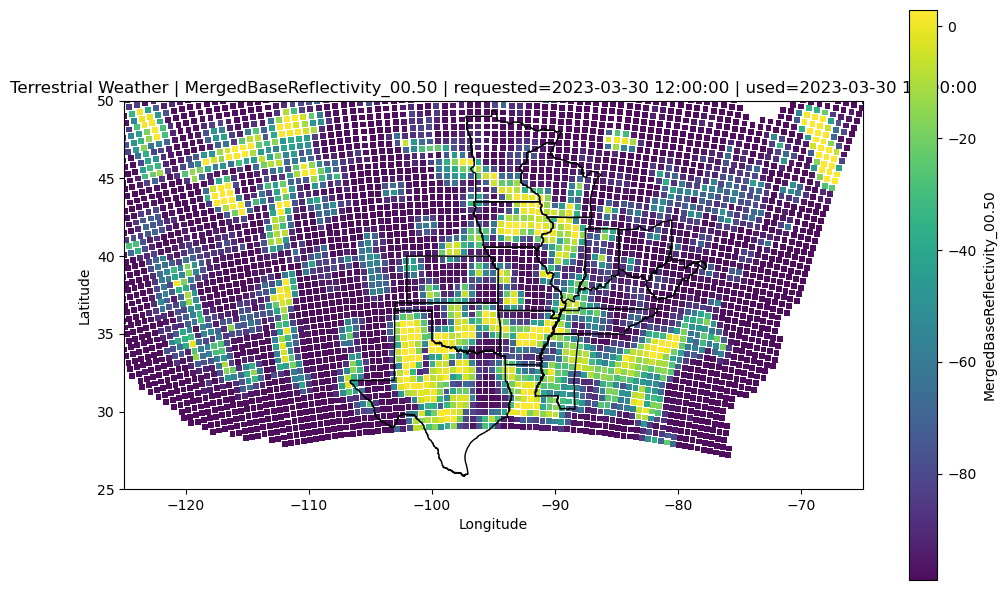

Wildfire stats | var=frp | used=2023-03-30 12:00:00 | n_valid=3765 | min=0 | max=1970 | mean=12.18


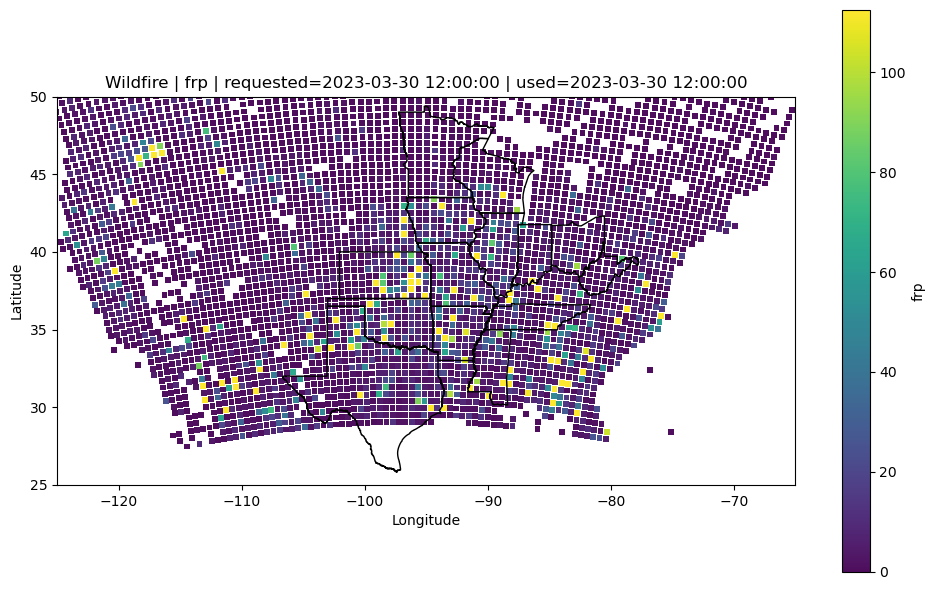

Space Weather stats | var=Eh | used=2023-03-30 12:00:00 | n_valid=1573 | min=0.04351 | max=80.12 | mean=4.641


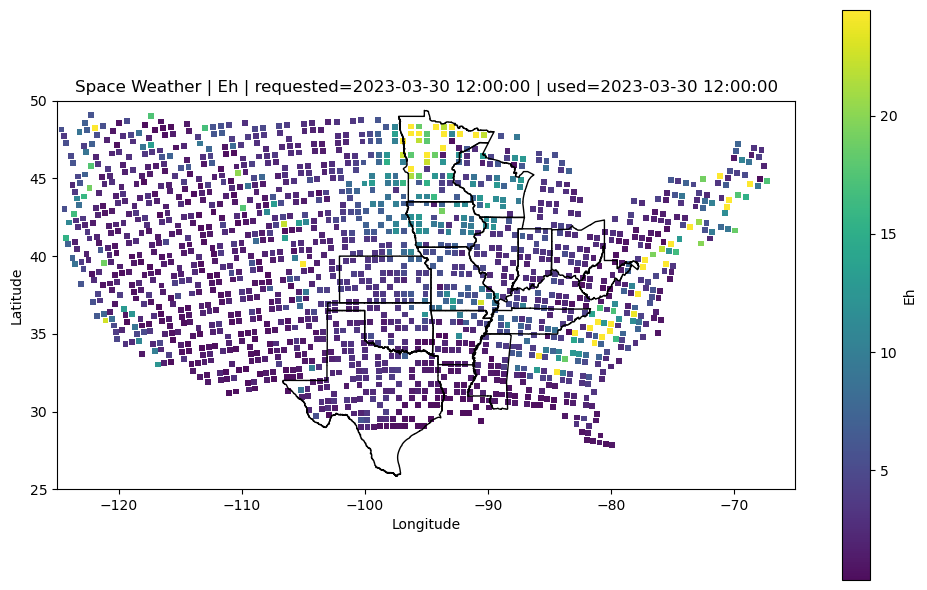

In [16]:
# Choose snapshot timestamp (can be overridden before running this cell)
VIS_TIMESTAMP = pd.Timestamp("2023-03-30 12:00:00")


def _pick_var(ds, preferred=None):
    vars_list = list(ds.data_vars)
    if preferred and preferred in vars_list:
        return preferred
    for candidate in ["frp", "Eh", "Bh", "MAX_SHEAR"]:
        if candidate in vars_list:
            return candidate
    for v in vars_list:
        if v.lower() not in {"lat", "lon"}:
            return v
    return vars_list[0]


def _pick_var_with_data(ds, ts, preferred=None):
    if ds is None or "time" not in ds.coords:
        return None
    vars_list = list(ds.data_vars)
    ordered = []
    if preferred and preferred in vars_list:
        ordered.append(preferred)
    ordered.extend([v for v in vars_list if v not in ordered])

    for v in ordered:
        da = ds[v].sel(time=ts, method="nearest")
        arr = np.asarray(da.values, dtype=float)
        fill_value = da.attrs.get("_FillValue", None)
        if fill_value is not None:
            arr[np.isclose(arr, float(fill_value))] = np.nan
        good = arr[np.isfinite(arr)]
        if good.size and good.min() <= -900:
            arr[arr <= -900] = np.nan
        if np.isfinite(arr).any():
            return v
    return ordered[0] if ordered else None


def _robust_limits(vals):
    good = vals[np.isfinite(vals)]
    if good.size == 0:
        return None, None
    vmin = np.nanpercentile(good, 2)
    vmax = np.nanpercentile(good, 98)
    if np.isclose(vmin, vmax):
        vmin = np.nanmin(good)
        vmax = np.nanmax(good)
    return float(vmin), float(vmax)


def _plot_hazard_snapshot(ds, var_name, title, ts, gdf_aoi_local):
    if ds is None:
        print(f"{title}: dataset is None")
        return
    if "time" not in ds.coords:
        print(f"{title}: no time coordinate")
        return

    ts = pd.Timestamp(ts).tz_localize(None) if pd.Timestamp(ts).tzinfo else pd.Timestamp(ts)
    selected = ds[var_name].sel(time=ts, method="nearest")
    used_time = pd.Timestamp(selected["time"].values)

    if "lat" not in ds.coords or "lon" not in ds.coords:
        print(f"{title}: missing lat/lon coords")
        return

    lat2d = ds["lat"].values
    lon2d = ds["lon"].values
    vals = selected.values.astype(float)

    # Mask common nodata encodings before plotting
    fill_value = selected.attrs.get("_FillValue", None)
    if fill_value is not None:
        vals[np.isclose(vals, float(fill_value))] = np.nan
    vals[vals <= -900] = np.nan

    flat_lat = lat2d.ravel()
    flat_lon = lon2d.ravel()
    flat_vals = vals.ravel()
    valid = np.isfinite(flat_vals)

    fig, ax = plt.subplots(figsize=(10, 6))

    if valid.sum() == 0:
        if gdf_aoi_local is not None and not gdf_aoi_local.empty:
            gdf_aoi_local.boundary.plot(ax=ax, color="black", linewidth=1.0)
        ax.text(-95, 37.5, "No valid data at selected timestamp", ha="center", va="center", fontsize=12)
        ax.set_title(f"{title} | {var_name} | requested={ts} | used={used_time}")
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.set_xlim(-125, -65)
        ax.set_ylim(25, 50)
        plt.tight_layout()
        plt.show()
        print(f"{title}: all values are NaN at {used_time}")
        return

    vmin, vmax = _robust_limits(flat_vals)

    print(
        f"{title} stats | var={var_name} | used={used_time} | "
        f"n_valid={int(valid.sum())} | min={np.nanmin(flat_vals):.4g} | "
        f"max={np.nanmax(flat_vals):.4g} | mean={np.nanmean(flat_vals):.4g}"
    )

    sc = ax.scatter(
        flat_lon[valid],
        flat_lat[valid],
        c=flat_vals[valid],
        s=18,
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        marker="s",
        linewidths=0,
        alpha=0.95,
    )
    plt.colorbar(sc, ax=ax, label=var_name)

    if gdf_aoi_local is not None and not gdf_aoi_local.empty:
        gdf_aoi_local.boundary.plot(ax=ax, color="black", linewidth=1.0)

    ax.set_title(f"{title} | {var_name} | requested={ts} | used={used_time}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_xlim(-125, -65)
    ax.set_ylim(25, 50)
    plt.tight_layout()
    plt.show()


# Ensure AOI is available in EPSG:4326 for overlay
if "gdf_aoi" in globals() and gdf_aoi is not None:
    gdf_aoi_plot = gdf_aoi.to_crs("EPSG:4326")
else:
    gdf_aoi_plot = gpd.read_file(PATH_AOI).to_crs("EPSG:4326")

# Get gridded hazard datasets
ds_tw = gridded_hazards.get("terrestrial_weather_gridded")
ds_wf = gridded_hazards.get("wildfire_gridded")
ds_sw = gridded_hazards.get("space_weather_gridded")

# Pick representative variables with actual data at this timestamp when possible
var_tw = _pick_var_with_data(ds_tw, VIS_TIMESTAMP, preferred="MAX_SHEAR") if ds_tw is not None else None
var_wf = _pick_var_with_data(ds_wf, VIS_TIMESTAMP, preferred="frp") if ds_wf is not None else None
var_sw = _pick_var_with_data(ds_sw, VIS_TIMESTAMP, preferred="Eh") if ds_sw is not None else None

print("Selected vars:", {"terrestrial_weather": var_tw, "wildfire": var_wf, "space_weather": var_sw})

# Three figures: one for each hazard
if ds_tw is not None and var_tw is not None:
    _plot_hazard_snapshot(ds_tw, var_tw, "Terrestrial Weather", VIS_TIMESTAMP, gdf_aoi_plot)
if ds_wf is not None and var_wf is not None:
    _plot_hazard_snapshot(ds_wf, var_wf, "Wildfire", VIS_TIMESTAMP, gdf_aoi_plot)
if ds_sw is not None and var_sw is not None:
    _plot_hazard_snapshot(ds_sw, var_sw, "Space Weather", VIS_TIMESTAMP, gdf_aoi_plot)

## Step 3: Ingest and Align Hazards

Read terrestrial weather, wildfire, and space-weather datasets and align them on the common grid and event timeline.

In [6]:
ds_grid = xr.open_dataset(PATH_ANALYSIS_GRID)
print(ds_grid)

# Best-effort extraction of analysis-cell geometries if available in the dataset.
if "geometry" in ds_grid.variables:
    df_grid = ds_grid[["geometry"]].to_dataframe().reset_index()
    gdf_grid = gpd.GeoDataFrame(df_grid, geometry=gpd.GeoSeries.from_wkt(df_grid["geometry"]), crs="EPSG:4326")
    print(f"Grid cells parsed from geometry variable: {len(gdf_grid):,}")
else:
    gdf_grid = None
    print("No direct geometry variable found in grid dataset; gridding adapter cell will be added next.")

<xarray.Dataset> Size: 93kB
Dimensions:  (y: 55, x: 104)
Coordinates:
  * x        (x) float64 832B -2.918e+06 -2.868e+06 ... 2.182e+06 2.232e+06
  * y        (y) float64 440B 6.668e+05 7.168e+05 ... 3.317e+06 3.367e+06
Data variables:
    lat      (y, x) float64 46kB ...
    lon      (y, x) float64 46kB ...
Attributes:
    proj:           EPSG:5070
    resolution_km:  50
    lat_min:        25
    lat_max:        50
    lon_min:        -125
    lon_max:        -65
    approx_dx_km:   49.82687240456757
    approx_dy_km:   49.884925435155075
No direct geometry variable found in grid dataset; gridding adapter cell will be added next.


## Cross-Hazard Normalization: Variable Selection and Snapshot QA

This section implements a practical normalization scheme that respects mixed dimensionality:

- **Physical variables**: robust quantile scaling.
- **Derived physical variables**: robust quantile scaling (separate class).
- **Statistical/diagnostic variables**: special handling (ARI/probability/categorical).
- **Reflectivity (dBZ)**: threshold-aware scaling in dBZ space.
- **Wildfire and space weather**: robust quantile scaling with hazard-specific labels.

The next cells render **raw vs normalized** side-by-side for:
1. Space weather (e.g., `Eh`)
2. Terrestrial physical
3. Terrestrial derived physical
4. Terrestrial statistical/diagnostic
5. Wildfire

In [13]:

# Timestamp used for side-by-side QA visualization
NORM_VIS_TIMESTAMP = pd.Timestamp("2023-03-30 20:00:00")


In [14]:
# Normalization helpers and variable selection for mixed-dimensional terrestrial hazards
import re


def _clean_vals_for_plot(da):
    arr = np.asarray(da.values, dtype=float)
    fill_value = da.attrs.get("_FillValue", None)
    if fill_value is not None:
        arr[np.isclose(arr, float(fill_value))] = np.nan
    arr[arr <= -900] = np.nan
    return arr


def _nearest_time_da(ds, var_name, ts):
    da = ds[var_name].sel(time=pd.Timestamp(ts), method="nearest")
    used_time = pd.Timestamp(da["time"].values)
    return da, used_time


def _robust_quantile_scale(arr, qlo=0.05, qhi=0.95):
    out = np.full(arr.shape, np.nan, dtype=float)
    good = np.isfinite(arr)
    if not good.any():
        return out
    lo, hi = np.nanquantile(arr[good], [qlo, qhi])
    if np.isclose(lo, hi):
        lo, hi = np.nanmin(arr[good]), np.nanmax(arr[good])
    if np.isclose(lo, hi):
        out[good] = 0.5
        return out
    out[good] = np.clip((arr[good] - lo) / (hi - lo), 0.0, 1.0)
    return out


def _normalize_ari(arr):
    # ARI behaves like inverse probability. Use log10(ARI) then robust scaling.
    x = np.full(arr.shape, np.nan, dtype=float)
    good = np.isfinite(arr) & (arr > 0)
    if good.any():
        x[good] = np.log10(arr[good])
    return _robust_quantile_scale(x)


def _normalize_probability(arr):
    x = np.full(arr.shape, np.nan, dtype=float)
    good = np.isfinite(arr)
    if not good.any():
        return x
    vals = arr[good]
    # Handle either [0,1] or [0,100] representations.
    if np.nanmax(vals) > 1.5:
        vals = vals / 100.0
    x[good] = np.clip(vals, 0.0, 1.0)
    return x


def _normalize_categorical(arr):
    x = np.full(arr.shape, np.nan, dtype=float)
    good = np.isfinite(arr)
    if not good.any():
        return x
    vals = arr[good]
    u = np.unique(vals)
    if len(u) == 1:
        x[good] = 0.0 if u[0] <= 0 else 1.0
        return x
    rank_map = {v: i / (len(u) - 1) for i, v in enumerate(np.sort(u))}
    x[good] = np.array([rank_map[v] for v in vals], dtype=float)
    return x


def _normalize_dbz(arr):
    # Keep dBZ space; map to convective-relevance band.
    x = np.full(arr.shape, np.nan, dtype=float)
    good = np.isfinite(arr)
    if good.any():
        x[good] = np.clip((arr[good] - 20.0) / 40.0, 0.0, 1.0)
    return x


def _infer_var_class(var_name):
    n = var_name.lower()
    if "dbz" in n or "reflect" in n:
        return "reflectivity"
    if "ari" in n:
        return "stat_ari"
    if "prob" in n or "percent" in n:
        return "stat_prob"
    if "cat" in n or "class" in n or "flag" in n:
        return "stat_categorical"
    if "vil" in n or "vii" in n or "ivt" in n or "pwat" in n:
        return "derived_physical"
    return "physical"


def normalize_hazard_field(arr, var_name, family):
    cls = _infer_var_class(var_name)
    if cls == "reflectivity":
        return _normalize_dbz(arr), "reflectivity_dBZ_threshold_scaled"
    if cls == "stat_ari":
        return _normalize_ari(arr), "log10_ARI_robust_scaled"
    if cls == "stat_prob":
        return _normalize_probability(arr), "probability_clipped_0_1"
    if cls == "stat_categorical":
        return _normalize_categorical(arr), "categorical_rank_scaled"
    # For physical / derived / wildfire / space weather use robust quantile scaling.
    return _robust_quantile_scale(arr), f"{family}_robust_q05_q95"


def _choose_var_by_patterns(ds, include_patterns, exclude_patterns=None, ts=None):
    if ds is None:
        return None
    exclude_patterns = exclude_patterns or []
    vars_list = list(ds.data_vars)

    def _matches(v, pats):
        lv = v.lower()
        return any(re.search(p, lv) for p in pats)

    candidates = [v for v in vars_list if _matches(v, include_patterns) and not _matches(v, exclude_patterns)]
    if not candidates:
        return None

    if ts is None:
        return candidates[0]

    # Prefer candidate with finite data at timestamp.
    for v in candidates:
        da = ds[v].sel(time=pd.Timestamp(ts), method="nearest")
        arr = _clean_vals_for_plot(da)
        if np.isfinite(arr).any():
            return v
    return candidates[0]


# Pull hazard datasets from gridded bundle
if "gridded_hazards" not in globals():
    raise RuntimeError("gridded_hazards is not defined. Run hazard ingest/gridding cell first.")

ds_tw = gridded_hazards.get("terrestrial_weather_gridded")
ds_wf = gridded_hazards.get("wildfire_gridded")
ds_sw = gridded_hazards.get("space_weather_gridded")

# Variable picks by terrestrial class
var_tw_physical = _choose_var_by_patterns(
    ds_tw,
    include_patterns=[r"u10", r"v10", r"wspd", r"gust", r"tmp", r"temp", r"precip", r"rain"],
    exclude_patterns=[r"ari", r"prob", r"cat", r"vil", r"vii", r"dbz", r"reflect"],
    ts=NORM_VIS_TIMESTAMP,
)

var_tw_derived = _choose_var_by_patterns(
    ds_tw,
    include_patterns=[r"vil", r"vii", r"ivt", r"pwat"],
    exclude_patterns=[r"ari", r"prob", r"cat"],
    ts=NORM_VIS_TIMESTAMP,
)

var_tw_stat = _choose_var_by_patterns(
    ds_tw,
    include_patterns=[r"ari", r"prob", r"cat", r"class", r"flag"],
    exclude_patterns=[],
    ts=NORM_VIS_TIMESTAMP,
)

# If no stat variable exists, try reflectivity as a dedicated diagnostic proxy.
if var_tw_stat is None:
    var_tw_stat = _choose_var_by_patterns(
        ds_tw,
        include_patterns=[r"dbz", r"reflect"],
        exclude_patterns=[],
        ts=NORM_VIS_TIMESTAMP,
    )

var_sw = _choose_var_by_patterns(ds_sw, include_patterns=[r"eh", r"bh", r"geo", r"electric"], ts=NORM_VIS_TIMESTAMP)
if var_sw is None and ds_sw is not None and len(ds_sw.data_vars) > 0:
    var_sw = list(ds_sw.data_vars)[0]

var_wf = _choose_var_by_patterns(ds_wf, include_patterns=[r"frp", r"fire", r"radiative"], ts=NORM_VIS_TIMESTAMP)
if var_wf is None and ds_wf is not None and len(ds_wf.data_vars) > 0:
    var_wf = list(ds_wf.data_vars)[0]

print("Selected variables for normalization QA:")
print({
    "space_weather": var_sw,
    "terrestrial_physical": var_tw_physical,
    "terrestrial_derived": var_tw_derived,
    "terrestrial_stat_or_diag": var_tw_stat,
    "wildfire": var_wf,
})

Selected variables for normalization QA:
{'space_weather': 'Bh', 'terrestrial_physical': 'PrecipRate_00.00', 'terrestrial_derived': 'VII_00.50', 'terrestrial_stat_or_diag': 'FLASH_QPE_ARI01H_00.00', 'wildfire': 'frp'}


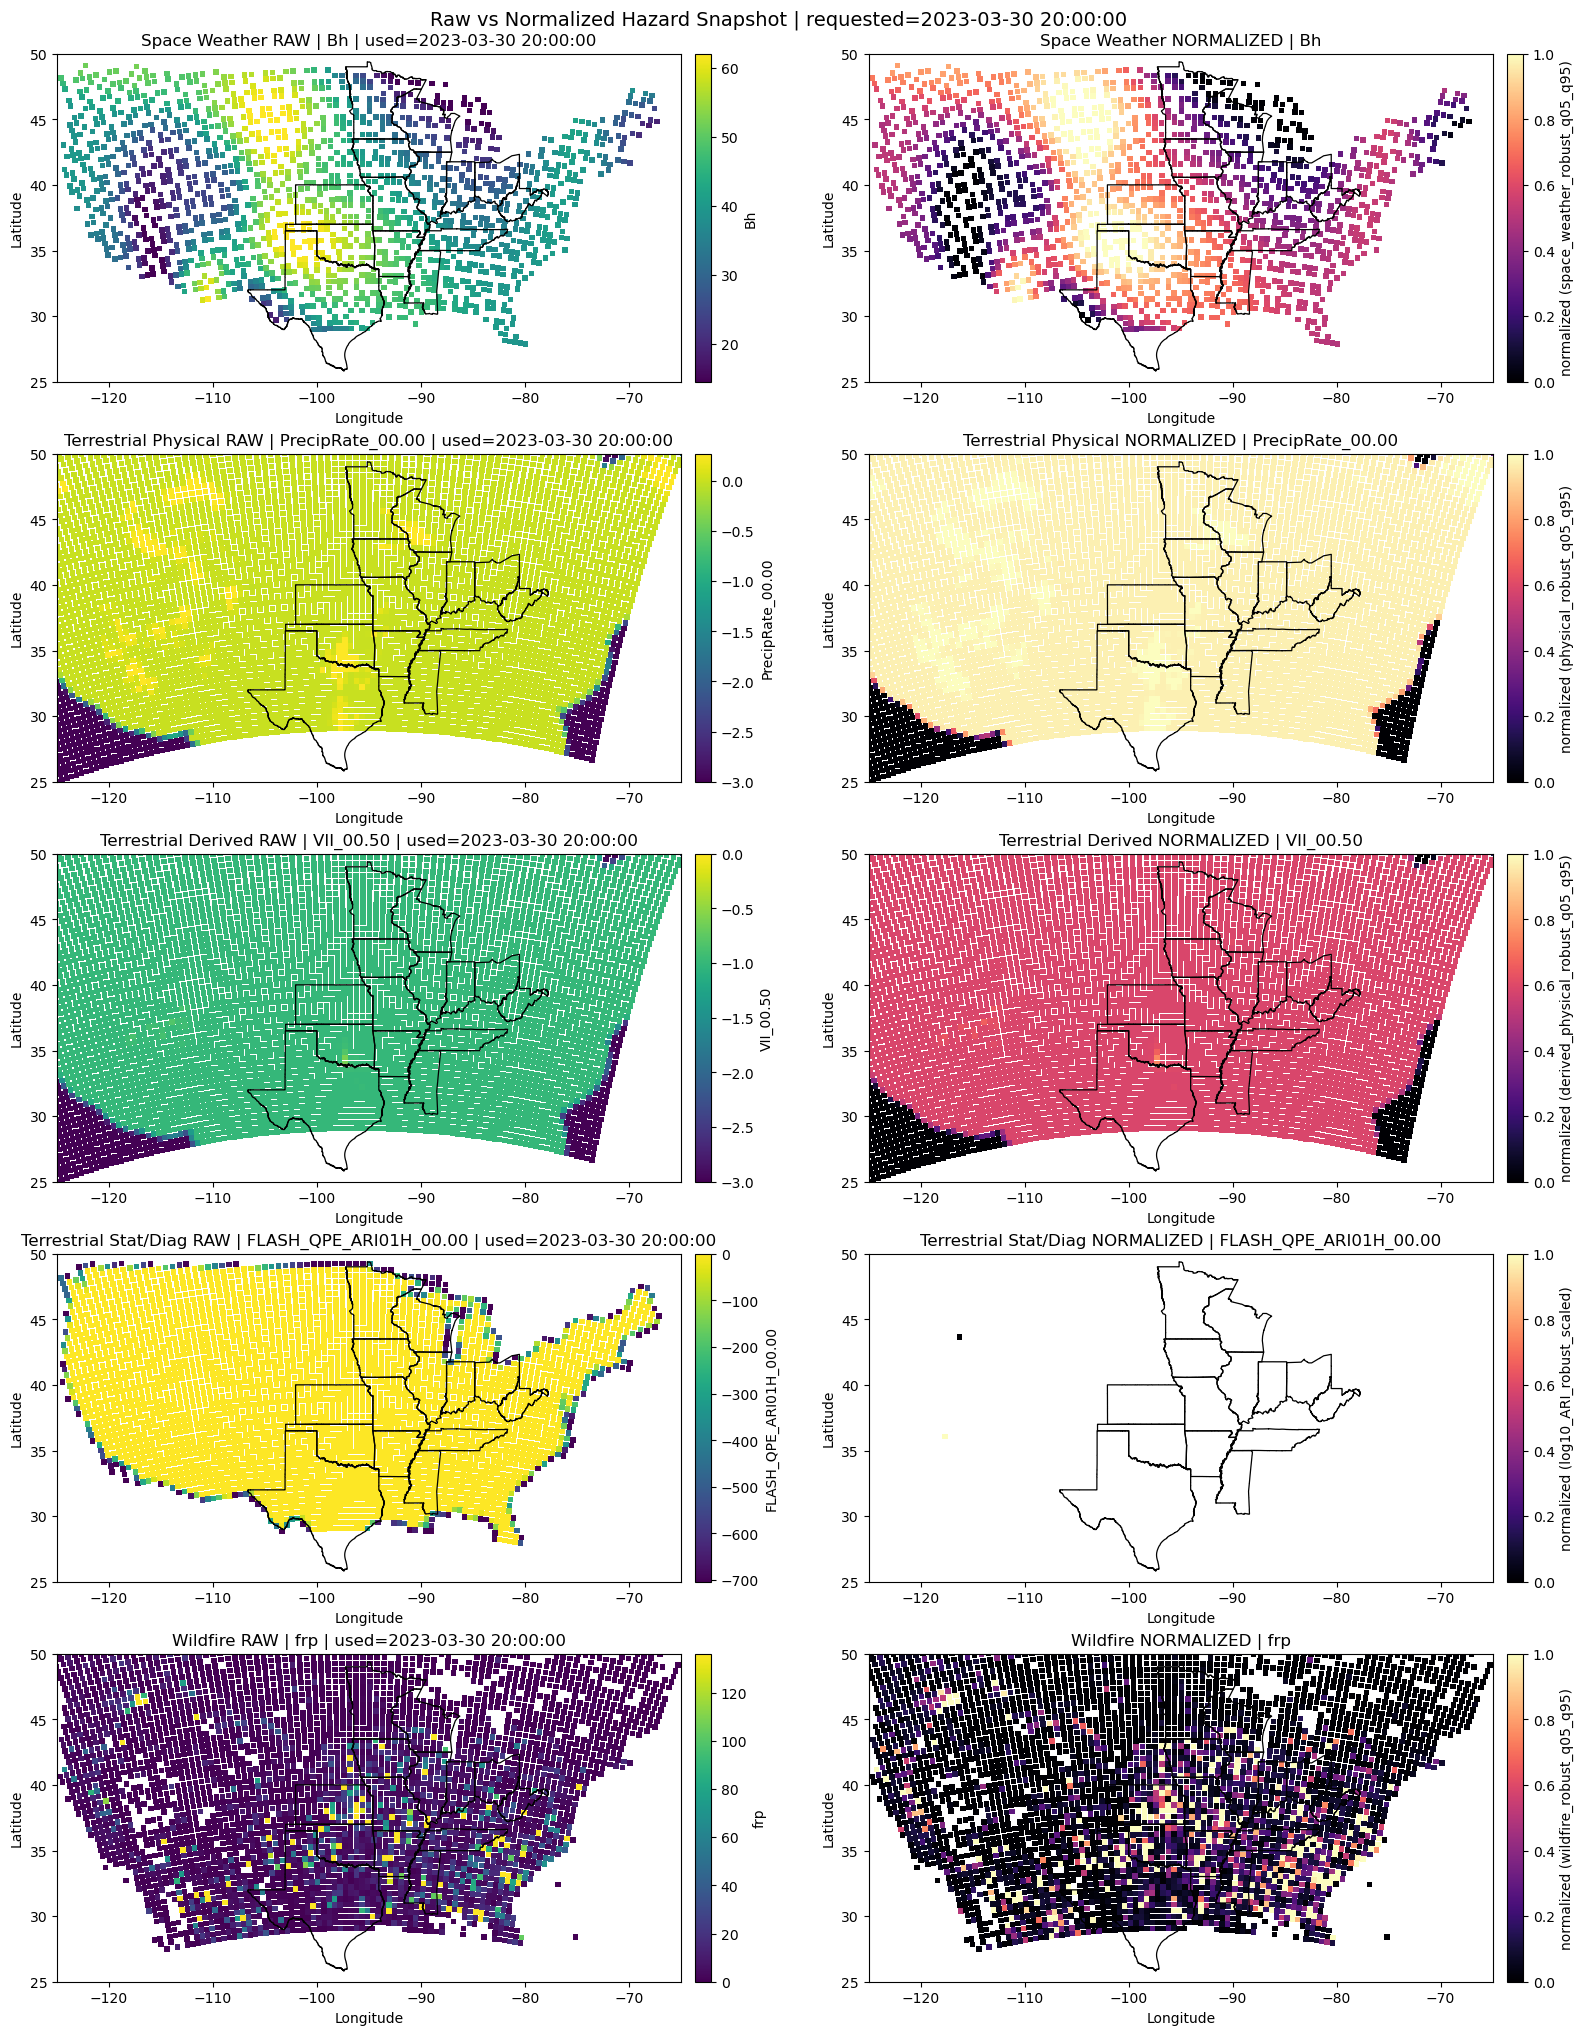

In [15]:
# Side-by-side snapshot: raw vs normalized for selected hazards

def _local_robust_limits(vals):
    good = vals[np.isfinite(vals)]
    if good.size == 0:
        return None, None
    vmin = np.nanpercentile(good, 2)
    vmax = np.nanpercentile(good, 98)
    if np.isclose(vmin, vmax):
        vmin = np.nanmin(good)
        vmax = np.nanmax(good)
    return float(vmin), float(vmax)


def _plot_raw_vs_normalized(ax_raw, ax_norm, ds, var_name, ts, title_prefix, family):
    if ds is None or var_name is None:
        ax_raw.axis("off")
        ax_norm.axis("off")
        ax_raw.text(0.5, 0.5, f"{title_prefix}: missing dataset/variable", ha="center", va="center")
        return

    da, used_time = _nearest_time_da(ds, var_name, ts)
    arr = _clean_vals_for_plot(da)

    if "lat" not in ds.coords or "lon" not in ds.coords:
        ax_raw.axis("off")
        ax_norm.axis("off")
        ax_raw.text(0.5, 0.5, f"{title_prefix}: missing lat/lon", ha="center", va="center")
        return

    lat2d = ds["lat"].values
    lon2d = ds["lon"].values
    flat_lat = lat2d.ravel()
    flat_lon = lon2d.ravel()
    flat_raw = arr.ravel()
    valid = np.isfinite(flat_raw)

    norm_arr, norm_label = normalize_hazard_field(arr, var_name, family)
    flat_norm = norm_arr.ravel()
    valid_norm = np.isfinite(flat_norm)

    if valid.any():
        vmin_raw, vmax_raw = _local_robust_limits(flat_raw)
        sc1 = ax_raw.scatter(
            flat_lon[valid], flat_lat[valid], c=flat_raw[valid], s=16, marker="s",
            linewidths=0, cmap="viridis", vmin=vmin_raw, vmax=vmax_raw
        )
        plt.colorbar(sc1, ax=ax_raw, fraction=0.045, pad=0.02, label=var_name)
    else:
        ax_raw.text(0.5, 0.5, "No valid raw data", ha="center", va="center", transform=ax_raw.transAxes)

    if valid_norm.any():
        sc2 = ax_norm.scatter(
            flat_lon[valid_norm], flat_lat[valid_norm], c=flat_norm[valid_norm], s=16, marker="s",
            linewidths=0, cmap="magma", vmin=0.0, vmax=1.0
        )
        plt.colorbar(sc2, ax=ax_norm, fraction=0.045, pad=0.02, label=f"normalized ({norm_label})")
    else:
        ax_norm.text(0.5, 0.5, "No valid normalized data", ha="center", va="center", transform=ax_norm.transAxes)

    for ax in [ax_raw, ax_norm]:
        if "gdf_aoi" in globals() and gdf_aoi is not None and not gdf_aoi.empty:
            gdf_aoi.to_crs("EPSG:4326").boundary.plot(ax=ax, color="black", linewidth=0.9)
        ax.set_xlim(-125, -65)
        ax.set_ylim(25, 50)
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")

    ax_raw.set_title(f"{title_prefix} RAW | {var_name} | used={used_time}")
    ax_norm.set_title(f"{title_prefix} NORMALIZED | {var_name}")


rows = [
    (ds_sw, var_sw, "Space Weather", "space_weather"),
    (ds_tw, var_tw_physical, "Terrestrial Physical", "physical"),
    (ds_tw, var_tw_derived, "Terrestrial Derived", "derived_physical"),
    (ds_tw, var_tw_stat, "Terrestrial Stat/Diag", "stat_diag"),
    (ds_wf, var_wf, "Wildfire", "wildfire"),
]

nrows = len(rows)
fig, axes = plt.subplots(nrows=nrows, ncols=2, figsize=(16, 4 * nrows), constrained_layout=True)

if nrows == 1:
    axes = np.array([axes])

for i, (ds, var_name, title_prefix, family) in enumerate(rows):
    _plot_raw_vs_normalized(
        ax_raw=axes[i, 0],
        ax_norm=axes[i, 1],
        ds=ds,
        var_name=var_name,
        ts=NORM_VIS_TIMESTAMP,
        title_prefix=title_prefix,
        family=family,
    )

fig.suptitle(f"Raw vs Normalized Hazard Snapshot | requested={pd.Timestamp(NORM_VIS_TIMESTAMP)}", fontsize=14, y=1.01)
plt.show()

## Refinement QA: Nodata/Range Audit and Zero-Inflation-Aware Normalization

This section refines normalization by:

1. Auditing nodata patterns and effective value ranges per selected variable.
2. Applying a **zero-inflation-aware** transform for sparse hazards (especially precipitation-like and wildfire fields):
   - keep zero mass at 0,
   - normalize positive tail robustly,
   - optionally blend with positive exceedance rank.
3. Rendering a 3-way comparison for each hazard:
   - raw,
   - v1 normalized,
   - refined normalized.

Variable diagnostics at snapshot (raw values):
- Space Weather | Bh | used=2023-03-30 20:00:00 | finite=1573/5720 (27.50%) | zero_frac=0.00% | q01=13.1 | q50=40.1 | q99=63
- Terrestrial Physical | PrecipRate_00.00 | used=2023-03-30 20:00:00 | finite=5720/5720 (100.00%) | zero_frac=81.10% | q01=-3 | q50=0 | q99=0.49
- Terrestrial Derived | VII_00.50 | used=2023-03-30 20:00:00 | finite=5720/5720 (100.00%) | zero_frac=15.56% | q01=-3 | q50=-1 | q99=0
- Terrestrial Stat/Diag | FLASH_QPE_ARI01H_00.00 | used=2023-03-30 20:00:00 | finite=4166/5720 (72.83%) | zero_frac=91.17% | q01=-803 | q50=0 | q99=0
- Wildfire | frp | used=2023-03-30 20:00:00 | finite=3765/5720 (65.82%) | zero_frac=40.61% | q01=0 | q50=1.48 | q99=223


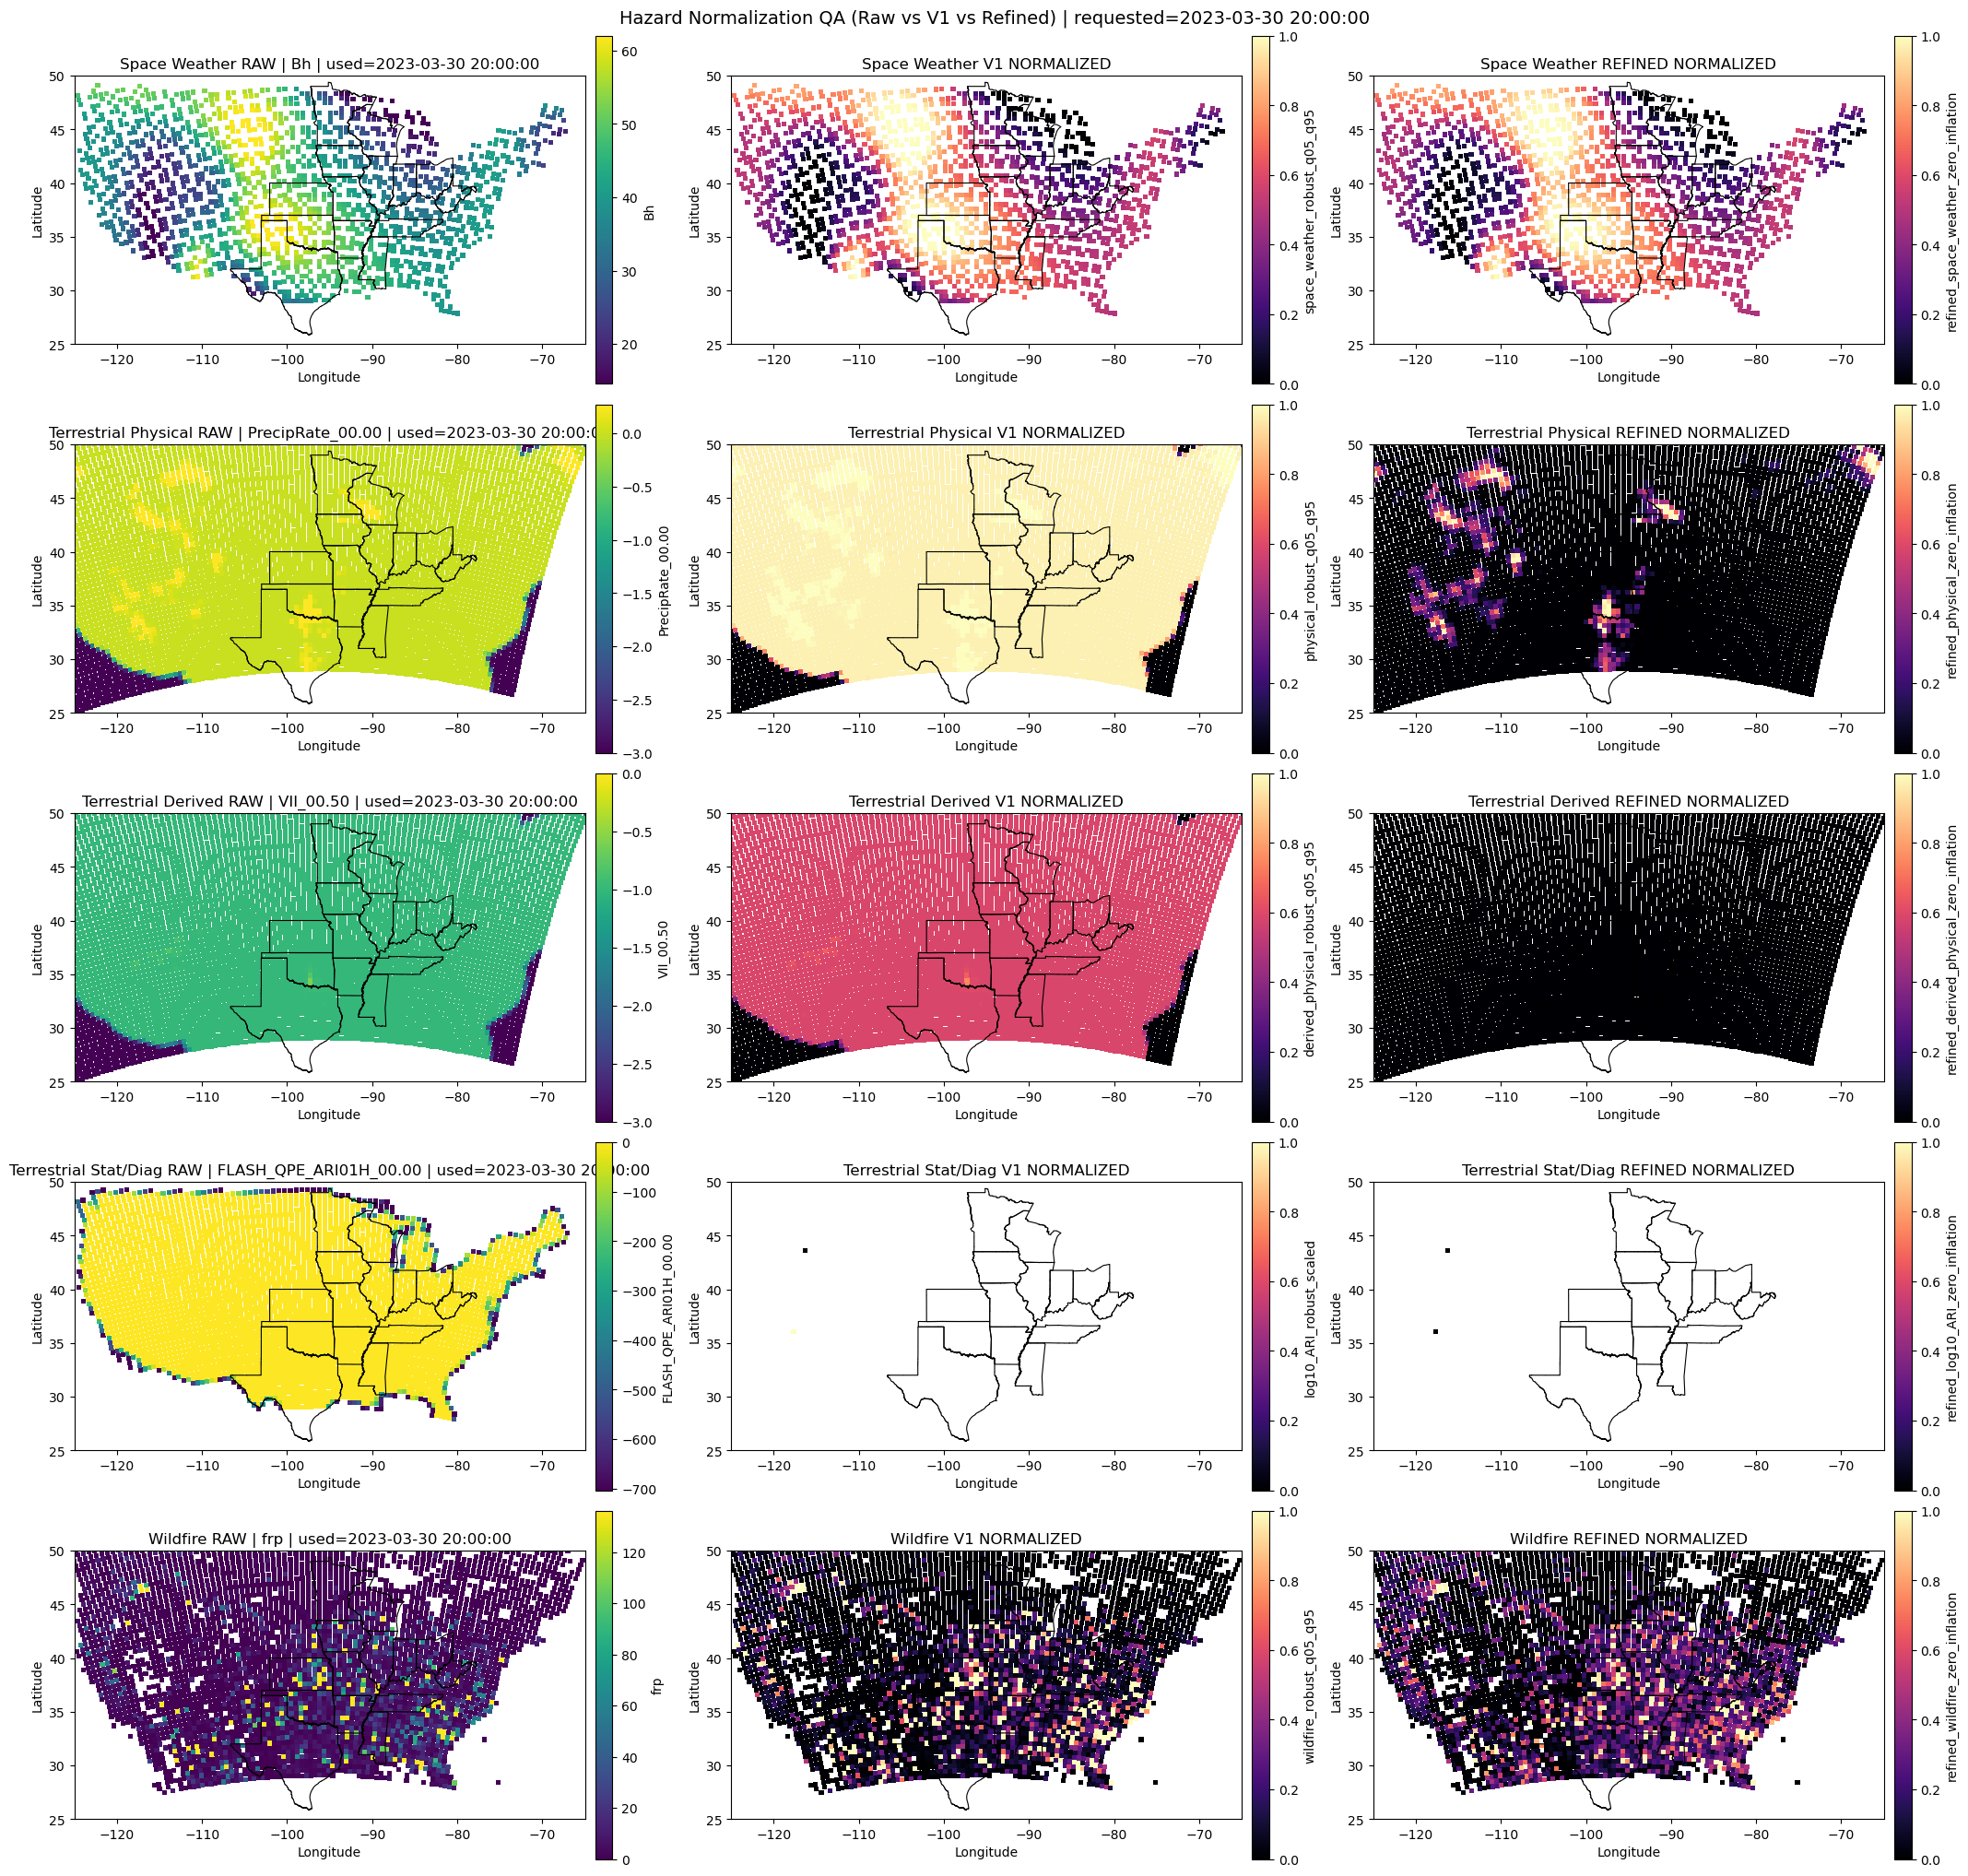

In [16]:
# Nodata/range diagnostics + refined normalization comparison (raw vs v1 vs refined)

def _array_diagnostics(arr):
    finite = np.isfinite(arr)
    n = arr.size
    n_finite = int(finite.sum())
    out = {
        "n_total": n,
        "n_finite": n_finite,
        "finite_frac": (n_finite / n) if n > 0 else np.nan,
        "zero_frac": np.nan,
        "q01": np.nan,
        "q50": np.nan,
        "q99": np.nan,
        "min": np.nan,
        "max": np.nan,
    }
    if n_finite > 0:
        vals = arr[finite]
        out["zero_frac"] = float(np.mean(np.isclose(vals, 0.0)))
        out["q01"], out["q50"], out["q99"] = [float(x) for x in np.nanquantile(vals, [0.01, 0.5, 0.99])]
        out["min"] = float(np.nanmin(vals))
        out["max"] = float(np.nanmax(vals))
    return out


def _zero_inflation_aware_scale(arr, qlo=0.05, qhi=0.95, blend_rank=0.35):
    """
    Refined scaling for sparse fields:
    - all non-positive values -> 0
    - positive values robustly scaled to [0,1]
    - blended with positive-only percentile rank to spread heavy tails
    """
    out = np.full(arr.shape, np.nan, dtype=float)
    finite = np.isfinite(arr)
    if not finite.any():
        return out

    vals = arr[finite]
    nonpos = vals <= 0
    pos = vals > 0

    scaled = np.zeros(vals.shape, dtype=float)
    if pos.any():
        pvals = vals[pos]
        lo, hi = np.nanquantile(pvals, [qlo, qhi])
        if np.isclose(lo, hi):
            lo, hi = np.nanmin(pvals), np.nanmax(pvals)
        if np.isclose(lo, hi):
            base = np.ones_like(pvals) * 0.5
        else:
            base = np.clip((pvals - lo) / (hi - lo), 0.0, 1.0)

        # Positive-only rank spread
        order = np.argsort(pvals)
        ranks = np.empty_like(order, dtype=float)
        ranks[order] = np.linspace(0.0, 1.0, len(pvals), endpoint=True)

        scaled[pos] = (1.0 - blend_rank) * base + blend_rank * ranks

    scaled[nonpos] = 0.0

    out_vals = np.full(vals.shape, np.nan, dtype=float)
    out_vals[:] = scaled
    out[finite] = out_vals
    return out


def normalize_hazard_field_refined(arr, var_name, family):
    cls = _infer_var_class(var_name)

    # Keep special cases
    if cls == "reflectivity":
        return _normalize_dbz(arr), "refined_reflectivity_dBZ_threshold"
    if cls == "stat_ari":
        # ARI as inverse-probability proxy; emphasize upper rarity structure in log-space
        x = np.full(arr.shape, np.nan, dtype=float)
        good = np.isfinite(arr) & (arr > 0)
        if good.any():
            x[good] = np.log10(arr[good])
        return _zero_inflation_aware_scale(x), "refined_log10_ARI_zero_inflation"
    if cls == "stat_prob":
        return _normalize_probability(arr), "refined_probability_0_1"
    if cls == "stat_categorical":
        return _normalize_categorical(arr), "refined_categorical_rank"

    # Physical/derived/wildfire/space: zero-aware scaling for sparse distributions
    return _zero_inflation_aware_scale(arr), f"refined_{family}_zero_inflation"


def _plot_raw_v1_refined(ax_raw, ax_v1, ax_ref, ds, var_name, ts, title_prefix, family):
    if ds is None or var_name is None:
        for ax in [ax_raw, ax_v1, ax_ref]:
            ax.axis("off")
        ax_raw.text(0.5, 0.5, f"{title_prefix}: missing dataset/variable", ha="center", va="center")
        return

    da, used_time = _nearest_time_da(ds, var_name, ts)
    arr = _clean_vals_for_plot(da)

    lat2d = ds["lat"].values
    lon2d = ds["lon"].values
    flat_lat = lat2d.ravel()
    flat_lon = lon2d.ravel()
    flat_raw = arr.ravel()
    valid_raw = np.isfinite(flat_raw)

    v1_arr, v1_label = normalize_hazard_field(arr, var_name, family)
    ref_arr, ref_label = normalize_hazard_field_refined(arr, var_name, family)
    flat_v1 = v1_arr.ravel()
    flat_ref = ref_arr.ravel()
    valid_v1 = np.isfinite(flat_v1)
    valid_ref = np.isfinite(flat_ref)

    # Raw
    if valid_raw.any():
        vmin_raw, vmax_raw = _local_robust_limits(flat_raw)
        sc_raw = ax_raw.scatter(flat_lon[valid_raw], flat_lat[valid_raw], c=flat_raw[valid_raw], s=14, marker="s",
                                linewidths=0, cmap="viridis", vmin=vmin_raw, vmax=vmax_raw)
        plt.colorbar(sc_raw, ax=ax_raw, fraction=0.045, pad=0.02, label=var_name)

    # V1 normalized
    if valid_v1.any():
        sc_v1 = ax_v1.scatter(flat_lon[valid_v1], flat_lat[valid_v1], c=flat_v1[valid_v1], s=14, marker="s",
                              linewidths=0, cmap="magma", vmin=0.0, vmax=1.0)
        plt.colorbar(sc_v1, ax=ax_v1, fraction=0.045, pad=0.02, label=v1_label)

    # Refined normalized
    if valid_ref.any():
        sc_ref = ax_ref.scatter(flat_lon[valid_ref], flat_lat[valid_ref], c=flat_ref[valid_ref], s=14, marker="s",
                                linewidths=0, cmap="magma", vmin=0.0, vmax=1.0)
        plt.colorbar(sc_ref, ax=ax_ref, fraction=0.045, pad=0.02, label=ref_label)

    for ax in [ax_raw, ax_v1, ax_ref]:
        if "gdf_aoi" in globals() and gdf_aoi is not None and not gdf_aoi.empty:
            gdf_aoi.to_crs("EPSG:4326").boundary.plot(ax=ax, color="black", linewidth=0.8)
        ax.set_xlim(-125, -65)
        ax.set_ylim(25, 50)
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")

    ax_raw.set_title(f"{title_prefix} RAW | {var_name} | used={used_time}")
    ax_v1.set_title(f"{title_prefix} V1 NORMALIZED")
    ax_ref.set_title(f"{title_prefix} REFINED NORMALIZED")


rows_refine = [
    (ds_sw, var_sw, "Space Weather", "space_weather"),
    (ds_tw, var_tw_physical, "Terrestrial Physical", "physical"),
    (ds_tw, var_tw_derived, "Terrestrial Derived", "derived_physical"),
    (ds_tw, var_tw_stat, "Terrestrial Stat/Diag", "stat_diag"),
    (ds_wf, var_wf, "Wildfire", "wildfire"),
]

# Diagnostics table printout
print("Variable diagnostics at snapshot (raw values):")
for ds, var_name, title_prefix, _family in rows_refine:
    if ds is None or var_name is None:
        print(f"- {title_prefix}: missing")
        continue
    da, used_time = _nearest_time_da(ds, var_name, NORM_VIS_TIMESTAMP)
    arr = _clean_vals_for_plot(da)
    d = _array_diagnostics(arr)
    print(
        f"- {title_prefix} | {var_name} | used={used_time} | "
        f"finite={d['n_finite']}/{d['n_total']} ({d['finite_frac']:.2%}) | "
        f"zero_frac={d['zero_frac']:.2%} | q01={d['q01']:.3g} | q50={d['q50']:.3g} | q99={d['q99']:.3g}"
    )

# 3-way comparison figure
nrows = len(rows_refine)
fig, axes = plt.subplots(nrows=nrows, ncols=3, figsize=(21, 4 * nrows), constrained_layout=True)
if nrows == 1:
    axes = np.array([axes])

for i, (ds, var_name, title_prefix, family) in enumerate(rows_refine):
    _plot_raw_v1_refined(
        ax_raw=axes[i, 0],
        ax_v1=axes[i, 1],
        ax_ref=axes[i, 2],
        ds=ds,
        var_name=var_name,
        ts=NORM_VIS_TIMESTAMP,
        title_prefix=title_prefix,
        family=family,
    )

fig.suptitle(f"Hazard Normalization QA (Raw vs V1 vs Refined) | requested={pd.Timestamp(NORM_VIS_TIMESTAMP)}", fontsize=14, y=1.01)
plt.show()

## Step 3b: Hazard Variable Screening and Interaction Candidates

This section performs an initial, hazard-only screening pass (before Whisker/Eagle-I target coupling):

1. Group terrestrial variables by mechanism: wind loading, convective severity, precipitation/flooding, icing, thermal stress.
2. Compute robustness diagnostics per variable (coverage, zero inflation, temporal variability, spatial variability).
3. Build a first-pass ranking per mechanism group.
4. Construct and summarize key interaction candidates:
   - wildfire × wind,
   - two-or-more hazards above median at same place/time,
   - high wind × vegetation-impact proxy,
   - lightning × wildfire ignition proxy,
   - GIC preconditioning (space weather lead interactions).

In [18]:
# Mechanism-based variable screening + interaction diagnostics (hazard-only first pass)
import re

if "gridded_hazards" not in globals():
    raise RuntimeError("gridded_hazards missing. Run hazard ingest cell first.")

# Ensure key handles exist
_ds_tw = gridded_hazards.get("terrestrial_weather_gridded")
_ds_wf = gridded_hazards.get("wildfire_gridded")
_ds_sw = gridded_hazards.get("space_weather_gridded")

if "NORM_VIS_TIMESTAMP" not in globals():
    NORM_VIS_TIMESTAMP = pd.Timestamp("2023-03-30 12:00:00")

# Local helpers (self-contained)
def _clean_vals(arr_like):
    arr = np.asarray(arr_like, dtype=float)
    arr[arr <= -900] = np.nan
    return arr

def _safe_sel(ds, var_name, ts):
    da = ds[var_name].sel(time=pd.Timestamp(ts), method="nearest")
    return da, pd.Timestamp(da["time"].values)

def _binary_above_median(arr):
    out = np.zeros(arr.shape, dtype=np.uint8)
    good = np.isfinite(arr)
    if not good.any():
        return out
    med = np.nanmedian(arr[good])
    out[good] = (arr[good] > med).astype(np.uint8)
    return out

def _screen_var(ds, var_name):
    da = ds[var_name]
    arr = _clean_vals(da.values)
    finite = np.isfinite(arr)
    if not finite.any():
        return {
            "var": var_name,
            "coverage": 0.0,
            "zero_frac": np.nan,
            "temporal_var": 0.0,
            "spatial_var": 0.0,
            "tail_ratio": np.nan,
            "score": 0.0,
        }

    vals = arr[finite]
    coverage = float(finite.mean())
    zero_frac = float(np.mean(np.isclose(vals, 0.0)))

    # Temporal and spatial variability metrics
    if arr.ndim == 3:  # time, y, x
        with np.errstate(invalid="ignore"):
            ts_mean = np.nanmean(arr, axis=(1, 2))
            sp_mean = np.nanmean(arr, axis=0)
        temporal_var = float(np.nanstd(ts_mean))
        spatial_var = float(np.nanstd(sp_mean))
    else:
        temporal_var = float(np.nanstd(vals))
        spatial_var = float(np.nanstd(vals))

    q50 = np.nanquantile(vals, 0.5)
    q95 = np.nanquantile(vals, 0.95)
    tail_ratio = float((q95 + 1e-9) / (abs(q50) + 1e-9))

    # Hazard-only screening score for first pass
    score = coverage * (1.0 - min(0.95, zero_frac)) * np.log1p(temporal_var + spatial_var) * np.log1p(max(0.0, tail_ratio - 1.0))

    return {
        "var": var_name,
        "coverage": coverage,
        "zero_frac": zero_frac,
        "temporal_var": temporal_var,
        "spatial_var": spatial_var,
        "tail_ratio": tail_ratio,
        "score": score,
    }


# Mechanism groups for terrestrial weather
MECH_GROUPS = {
    "wind_loading": [r"u10", r"v10", r"wspd", r"gust", r"wind"],
    "convective_severity": [r"shear", r"dbz", r"reflect", r"cape", r"vil", r"vii", r"hail", r"torn"],
    "precip_flooding": [r"precip", r"rain", r"qpe", r"flood", r"ari", r"pwat", r"ivt"],
    "icing": [r"ice", r"freez", r"frzr", r"sleet", r"snow"],
    "thermal": [r"temp", r"tmp", r"heat", r"cold", r"dew", r"rh"],
}

all_tw_vars = list(_ds_tw.data_vars) if _ds_tw is not None else []

def _match_any(name, pats):
    n = name.lower()
    return any(re.search(p, n) for p in pats)

group_rows = []
for grp, pats in MECH_GROUPS.items():
    grp_vars = [v for v in all_tw_vars if _match_any(v, pats)]
    for v in grp_vars:
        d = _screen_var(_ds_tw, v)
        d["group"] = grp
        group_rows.append(d)

var_screen_df = pd.DataFrame(group_rows)
if var_screen_df.empty:
    print("No terrestrial variables matched mechanism patterns.")
else:
    var_screen_df = var_screen_df.sort_values(["group", "score"], ascending=[True, False])
    print("Top 5 candidates per mechanism group (hazard-only screening):")
    for grp in MECH_GROUPS.keys():
        sub = var_screen_df[var_screen_df["group"] == grp].head(5)
        if len(sub) == 0:
            continue
        print(f"\n[{grp}]")
        print(sub[["var", "score", "coverage", "zero_frac", "tail_ratio"]].to_string(index=False))


# Pick representative variables for interaction diagnostics
# Wind variable preference: vector-consistent components first, then speed proxies
wind_var = None
for cand in ["u10", "v10", "wspd10", "wind_speed", "gust10"]:
    if cand in all_tw_vars:
        wind_var = cand
        break
if wind_var is None:
    wind_var = next((v for v in all_tw_vars if re.search(r"u10|v10|wspd|gust|wind", v.lower())), None)

lightning_var = next((v for v in all_tw_vars if re.search(r"lightning|ltg|flash", v.lower())), None)

space_var = var_sw if "var_sw" in globals() and var_sw in list(_ds_sw.data_vars) else (list(_ds_sw.data_vars)[0] if _ds_sw is not None and len(_ds_sw.data_vars) > 0 else None)
wildfire_var = var_wf if "var_wf" in globals() and var_wf in list(_ds_wf.data_vars) else (list(_ds_wf.data_vars)[0] if _ds_wf is not None and len(_ds_wf.data_vars) > 0 else None)

# One convective and one precip variable from screening
conv_var = None
precip_var = None
if "var_screen_df" in globals() and isinstance(var_screen_df, pd.DataFrame) and not var_screen_df.empty:
    conv_sub = var_screen_df[var_screen_df["group"] == "convective_severity"]
    precip_sub = var_screen_df[var_screen_df["group"] == "precip_flooding"]
    conv_var = conv_sub.iloc[0]["var"] if len(conv_sub) else None
    precip_var = precip_sub.iloc[0]["var"] if len(precip_sub) else None

print("\nInteraction variable choices:")
print({
    "wind_var": wind_var,
    "convective_var": conv_var,
    "precip_var": precip_var,
    "wildfire_var": wildfire_var,
    "lightning_var": lightning_var,
    "space_weather_var": space_var,
})

# Build binary exceedance masks at a consistent timestamp stack
def _to_binary_cube(ds, var_name):
    if ds is None or var_name is None:
        return None
    arr = _clean_vals(ds[var_name].values)
    return _binary_above_median(arr)

b_wind = _to_binary_cube(_ds_tw, wind_var)
b_conv = _to_binary_cube(_ds_tw, conv_var)
b_precip = _to_binary_cube(_ds_tw, precip_var)
b_wildfire = _to_binary_cube(_ds_wf, wildfire_var)
b_lightning = _to_binary_cube(_ds_tw, lightning_var)
b_space = _to_binary_cube(_ds_sw, space_var)

# Harmonize time dimension length for interactions across datasets
def _trim_time(arr, n):
    if arr is None:
        return None
    return arr[:n]

cubes = [x for x in [b_wind, b_conv, b_precip, b_wildfire, b_lightning, b_space] if x is not None]
if not cubes:
    raise RuntimeError("No interaction cubes available.")
ntime = min(c.shape[0] for c in cubes)

b_wind = _trim_time(b_wind, ntime)
b_conv = _trim_time(b_conv, ntime)
b_precip = _trim_time(b_precip, ntime)
b_wildfire = _trim_time(b_wildfire, ntime)
b_lightning = _trim_time(b_lightning, ntime)
b_space = _trim_time(b_space, ntime)

interaction_stats = []

def _rate(arr):
    if arr is None:
        return np.nan
    return float(np.mean(arr > 0))

# 1) Wildfire x wind
if b_wildfire is not None and b_wind is not None:
    inter = (b_wildfire & b_wind).astype(np.uint8)
    interaction_stats.append({"interaction": "wildfire_x_wind", "rate": _rate(inter)})

# 2) Any 2+ hazards above median (same time/place)
stack_for_combo = [x for x in [b_wind, b_conv, b_precip, b_wildfire, b_space] if x is not None]
if stack_for_combo:
    combo = (np.sum(np.stack(stack_for_combo, axis=0), axis=0) >= 2).astype(np.uint8)
    interaction_stats.append({"interaction": "two_or_more_hazards_above_median", "rate": _rate(combo)})

# 3) High wind x vegetation-impact proxy (using wildfire presence as proxy)
if b_wind is not None and b_wildfire is not None:
    veg_proxy = (b_wind & b_wildfire).astype(np.uint8)
    interaction_stats.append({"interaction": "high_wind_x_vegetation_proxy", "rate": _rate(veg_proxy)})

# 4) Lightning driving wildfire ignition (lead-lag proxy)
if b_lightning is not None and b_wildfire is not None:
    lags = [1, 2, 4]  # 1h, 2h, 4h if hourly data
    for lag in lags:
        if lag < ntime:
            lead = b_lightning[:-lag]
            resp = b_wildfire[lag:]
            cond = lead > 0
            p_resp = float(np.mean(resp[cond] > 0)) if np.any(cond) else np.nan
            base = float(np.mean(resp > 0))
            interaction_stats.append({"interaction": f"lightning_leads_wildfire_lag{lag}", "rate": p_resp, "baseline": base, "lift": (p_resp / base) if base > 0 else np.nan})

# 5) GIC preconditioning: space weather leading other hazards/disruption proxies
if b_space is not None:
    for target_name, target_cube in [("wind", b_wind), ("convective", b_conv), ("wildfire", b_wildfire)]:
        if target_cube is None:
            continue
        for lag in [1, 2, 4]:
            if lag < ntime:
                lead = b_space[:-lag]
                resp = target_cube[lag:]
                cond = lead > 0
                p_resp = float(np.mean(resp[cond] > 0)) if np.any(cond) else np.nan
                base = float(np.mean(resp > 0))
                interaction_stats.append({"interaction": f"spaceweather_leads_{target_name}_lag{lag}", "rate": p_resp, "baseline": base, "lift": (p_resp / base) if base > 0 else np.nan})

interaction_df = pd.DataFrame(interaction_stats)
print("\nInteraction summary:")
if interaction_df.empty:
    print("No interactions computed.")
else:
    show_cols = [c for c in ["interaction", "rate", "baseline", "lift"] if c in interaction_df.columns]
    print(interaction_df[show_cols].to_string(index=False))

# Optional hook for target-based scoring (if user injects merged panel later)
print("\nTarget-coupled variable scoring note:")
if "hazard_obs_panel" in globals():
    print("hazard_obs_panel detected: ready to run lead-lag AUC scoring in next cell.")
else:
    print("hazard_obs_panel not found yet. Next step: join hazard features with Whisker/Eagle-I targets and run AUC-based lead-lag screening.")

/var/folders/g_/2j33jfhn72j448cr82hzgr0c0002d4/T/ipykernel_9413/587799294.py:57: RuntimeWarning: Mean of empty slice
  sp_mean = np.nanmean(arr, axis=0)


Top 5 candidates per mechanism group (hazard-only screening):

[wind_loading]
   var    score  coverage  zero_frac  tail_ratio
   v10 5.794565       1.0   0.000010   73.823401
   u10 2.697251       1.0   0.000010   10.502509
wspd10 1.211360       1.0   0.000005    2.569850

[convective_severity]
                              var  score  coverage  zero_frac  tail_ratio
                        MAX_SHEAR    0.0  0.000000        NaN         NaN
                              VIL    0.0  0.000000        NaN         NaN
                      MAX_REFLECT    0.0  0.000000        NaN         NaN
     MergedBaseReflectivity_00.50    0.0  0.947206   0.164268    0.081831
MergedReflectivityComposite_00.50    0.0  0.948133   0.164106    0.156816

[precip_flooding]
                            var     score  coverage  zero_frac   tail_ratio
MultiSensor_QPE_24H_Pass2_00.00 11.733707  1.000000   0.636001 1.072196e+10
               PrecipFlag_00.00  3.422284  1.000000   0.752956 1.166667e+09
            

In [19]:
# Step 3b refinement: enforce coverage-aware variable choices for interaction analysis
if "var_screen_df" not in globals() or var_screen_df.empty:
    raise RuntimeError("Run Step 3b screening cell first.")

def _pick_best(group_name, min_cov=0.5, min_score=0.0):
    sub = var_screen_df[var_screen_df["group"] == group_name].copy()
    if sub.empty:
        return None
    sub = sub[(sub["coverage"] >= min_cov) & (sub["score"] > min_score)]
    if sub.empty:
        return None
    return sub.sort_values("score", ascending=False).iloc[0]["var"]

wind_refined = _pick_best("wind_loading", min_cov=0.7, min_score=0.01)
conv_refined = _pick_best("convective_severity", min_cov=0.7, min_score=0.01)
precip_refined = _pick_best("precip_flooding", min_cov=0.7, min_score=0.01)

print("Coverage-aware picks:")
print({
    "wind": wind_refined,
    "convective": conv_refined,
    "precip": precip_refined,
})

print("\nTop convective candidates with nonzero score:")
conv_nonzero = var_screen_df[(var_screen_df["group"] == "convective_severity") & (var_screen_df["score"] > 0)].sort_values("score", ascending=False)
if conv_nonzero.empty:
    print("None found under current scoring. Consider alternate convective proxy (e.g., reflectivity percentile exceedance) in next pass.")
else:
    print(conv_nonzero[["var", "score", "coverage", "zero_frac", "tail_ratio"]].head(8).to_string(index=False))

Coverage-aware picks:
{'wind': 'v10', 'convective': None, 'precip': 'MultiSensor_QPE_24H_Pass2_00.00'}

Top convective candidates with nonzero score:
None found under current scoring. Consider alternate convective proxy (e.g., reflectivity percentile exceedance) in next pass.


## Step 4: Hazard to Stress Mapping (Grid to Components)

Project normalized hazard states from grid cells to transmission lines and substation elements to create component-level stress vectors.

In [ ]:
def build_substation_points(powergrid_gdf):
    """Build candidate substation points from line endpoints."""
    records = []
    for idx, geom in enumerate(powergrid_gdf.geometry):
        if geom is None:
            continue
        if geom.geom_type == "LineString":
            endpoints = [Point(geom.coords[0]), Point(geom.coords[-1])]
        elif geom.geom_type == "MultiLineString":
            endpoints = []
            for line in geom.geoms:
                endpoints.extend([Point(line.coords[0]), Point(line.coords[-1])])
        else:
            continue
        for p in endpoints:
            records.append({"line_idx": idx, "geometry": p})

    gdf_substations = gpd.GeoDataFrame(records, geometry="geometry", crs=powergrid_gdf.crs)
    return gdf_substations


def initialize_stress_vectors(powergrid_gdf, substations_gdf):
    """Initialize line/substation stress vectors for later hazard projection."""
    line_stress = pd.DataFrame({
        "line_idx": powergrid_gdf.index,
        "stress_state": 0.0,
    })
    substation_stress = pd.DataFrame({
        "substation_idx": substations_gdf.index,
        "stress_state": 0.0,
    })
    return line_stress, substation_stress


gdf_substations = build_substation_points(gdf_powergrid_aoi)
line_stress_df, substation_stress_df = initialize_stress_vectors(gdf_powergrid_aoi, gdf_substations)

print(f"Substation point candidates: {len(gdf_substations):,}")
print(f"Line stress vector length: {len(line_stress_df):,}")
print(f"Substation stress vector length: {len(substation_stress_df):,}")

## Step 5-7: Stress to Disruption to Spread Diagnostics

Placeholder for linking component stress to outage/disruption observations and evaluating propagation/spread across network and neighboring regions.

In [ ]:
def summarize_explanatory_support(line_stress_df, substation_stress_df, obs_paths):
    """Placeholder summary for explanatory support diagnostics."""
    summary = {
        "line_elements": int(len(line_stress_df)),
        "substation_elements": int(len(substation_stress_df)),
        "configured_observations": [k for k, v in obs_paths.items() if v is not None],
        "pending_observations": [k for k, v in obs_paths.items() if v is None],
    }
    return summary


support_summary = summarize_explanatory_support(line_stress_df, substation_stress_df, OBS_PATHS)
print("Event reconstruction scaffold summary:")
print(support_summary)

## Step 3c: Convective Proxy Builder + Impact Data Ingest

Build a robust convective hazard proxy from available terrestrial-weather channels, then ingest Whisker and Eagle-I impact datasets for hazard-to-impact coupling.

In [20]:
# Convective proxy builder (coverage-aware, percentile-based)
import json

if "gridded_hazards" not in globals() or "terrestrial_weather_gridded" not in gridded_hazards:
    raise RuntimeError("Missing terrestrial weather dataset in gridded_hazards.")


ds_tw = gridded_hazards["terrestrial_weather_gridded"]
all_tw_vars = list(ds_tw.data_vars)


def _find_first(patterns, names):
    for p in patterns:
        for n in names:
            if re.search(p, n.lower()):
                return n
    return None


def _safe_standardize(da):
    arr = da.values.astype(float)
    arr[arr <= -900] = np.nan
    good = np.isfinite(arr)
    if not good.any():
        return xr.DataArray(np.zeros_like(arr, dtype=np.float32), dims=da.dims, coords=da.coords)
    q05, q95 = np.nanquantile(arr[good], [0.05, 0.95])
    if not np.isfinite(q95 - q05) or (q95 - q05) <= 1e-9:
        out = np.zeros_like(arr, dtype=np.float32)
    else:
        out = (arr - q05) / (q95 - q05)
        out = np.clip(out, 0.0, 1.0)
    out[~good] = np.nan
    return xr.DataArray(out.astype(np.float32), dims=da.dims, coords=da.coords)


# Candidate channels: reflectivity + shear + lightning
refl_var = _find_first([r"reflectivitycomposite", r"basereflectivity", r"max_reflect", r"reflect"], all_tw_vars)
shear_var = _find_first([r"shear"], all_tw_vars)
lightning_var = _find_first([r"lightning", r"ltg", r"flash"], all_tw_vars)

proxy_terms = []
weights = []

if refl_var is not None:
    proxy_terms.append(_safe_standardize(ds_tw[refl_var]))
    weights.append(0.50)
if shear_var is not None:
    proxy_terms.append(_safe_standardize(ds_tw[shear_var]))
    weights.append(0.30)
if lightning_var is not None:
    proxy_terms.append(_safe_standardize(ds_tw[lightning_var]))
    weights.append(0.20)

if not proxy_terms:
    raise RuntimeError("No convective proxy ingredients found (reflectivity/shear/lightning).")

w = np.array(weights, dtype=float)
w = w / w.sum()
conv_proxy = sum(float(wi) * term for wi, term in zip(w, proxy_terms))
conv_proxy.name = "convective_proxy"
conv_proxy.attrs["builder"] = "weighted_percentile_standardized_reflectivity_shear_lightning"
conv_proxy.attrs["source_vars"] = json.dumps({
    "reflectivity": refl_var,
    "shear": shear_var,
    "lightning": lightning_var,
})

# Persist back into hazard container
if "convective_proxy" in ds_tw.data_vars:
    ds_tw = ds_tw.drop_vars("convective_proxy")
ds_tw["convective_proxy"] = conv_proxy
gridded_hazards["terrestrial_weather_gridded"] = ds_tw

print("Convective proxy created.")
print({
    "reflectivity": refl_var,
    "shear": shear_var,
    "lightning": lightning_var,
    "weights": dict(zip([v for v in [refl_var, shear_var, lightning_var] if v is not None], list(w))),
})
print("Proxy coverage:", float(np.isfinite(conv_proxy.values).mean()))

Convective proxy created.
{'reflectivity': 'MergedReflectivityComposite_00.50', 'shear': 'MAX_SHEAR', 'lightning': 'FLASH_QPE_ARI01H_00.00', 'weights': {'MergedReflectivityComposite_00.50': 0.5, 'MAX_SHEAR': 0.3, 'FLASH_QPE_ARI01H_00.00': 0.2}}
Proxy coverage: 0.7226341366966367


In [23]:
# Read Whisker + Eagle-I impacts and build hourly county panel (event window)
from pathlib import Path

WHISKER_DIR = Path("/Users/ryanmc/Documents/NASA_JPL/Projects/NaturalHazards/NASA ROSES Disasters 2025-2027/data/Whisker_Labs_Data_March2026/2023-03-26 to 2023-04-09 Event")
EAGLE_DIR = Path("/Users/ryanmc/Documents/Conferences/Jack_Eddy_Symposium_2022/dev/outage_data/EAGLE-I")

# ---- Whisker outages ----
whisker_file = WHISKER_DIR / "PowerOutages.json"
if not whisker_file.exists():
    raise FileNotFoundError(f"Whisker file not found: {whisker_file}")

with open(whisker_file, "r", encoding="utf-8") as f:
    whisker_raw = json.load(f)

if isinstance(whisker_raw, dict) and "features" in whisker_raw:
    whisker_iter = whisker_raw["features"]
elif isinstance(whisker_raw, list):
    whisker_iter = whisker_raw
else:
    raise ValueError("Unexpected Whisker structure. Expected list or dict with 'features'.")

w_rows = []
for r in whisker_iter:
    loc = r.get("Location") or {}
    w_rows.append({
        "start_utc": pd.to_datetime(r.get("StartTime"), errors="coerce", utc=True),
        "start_local": pd.to_datetime(r.get("StartTimeLocal"), errors="coerce"),
        "sensors": pd.to_numeric(r.get("Sensors"), errors="coerce"),
        "average_amplitude": pd.to_numeric(r.get("AverageAmplitude"), errors="coerce"),
        "lat": pd.to_numeric(loc.get("Latitude"), errors="coerce"),
        "lon": pd.to_numeric(loc.get("Longitude"), errors="coerce"),
        "type": r.get("Type"),
    })

whisker_df = pd.DataFrame(w_rows)
whisker_df = whisker_df.dropna(subset=["start_utc", "lat", "lon"]).copy()
whisker_df = whisker_df[(whisker_df["start_utc"] >= EVENT_START) & (whisker_df["start_utc"] <= EVENT_END)].copy()
whisker_df["hour"] = whisker_df["start_utc"].dt.floor("h")
whisker_df["sensors"] = whisker_df["sensors"].fillna(1.0)

# Map points to county_fips via AOI county geometry if available
if "counties_aoi" in globals() and isinstance(counties_aoi, gpd.GeoDataFrame):
    county_ref = counties_aoi.copy()
elif "counties" in globals() and isinstance(counties, gpd.GeoDataFrame):
    county_ref = counties.copy()
else:
    county_ref = None

if county_ref is not None and len(county_ref) > 0:
    w_gdf = gpd.GeoDataFrame(
        whisker_df,
        geometry=gpd.points_from_xy(whisker_df["lon"], whisker_df["lat"]),
        crs="EPSG:4326",
    )
    county_ref = county_ref.to_crs("EPSG:4326")

    fips_col = next((c for c in ["county_fips", "GEOID", "FIPS", "fips"] if c in county_ref.columns), None)
    if fips_col is not None:
        joined = gpd.sjoin(w_gdf, county_ref[[fips_col, "geometry"]], how="left", predicate="within")
        whisker_df["county_fips"] = joined[fips_col].astype(str).str.zfill(5)
    else:
        whisker_df["county_fips"] = np.nan
else:
    whisker_df["county_fips"] = np.nan

whisker_hourly = (
    whisker_df
    .dropna(subset=["hour"]) 
    .groupby(["hour", "county_fips"], dropna=False)
    .agg(
        whisker_event_count=("type", "size"),
        whisker_sensors_sum=("sensors", "sum"),
    )
    .reset_index()
)
whisker_hourly["county_fips"] = whisker_hourly["county_fips"].replace({"nan": np.nan}).fillna("00000").astype(str).str.zfill(5)

# ---- Eagle-I county outages ----
eagle_candidates = sorted(EAGLE_DIR.glob("*2023*county_outage_data*.csv"))
if len(eagle_candidates) == 0:
    eagle_candidates = sorted(EAGLE_DIR.glob("*county_outage_data*.csv"))
if len(eagle_candidates) == 0:
    raise FileNotFoundError(f"No Eagle-I county outage CSV found in {EAGLE_DIR}")

eagle_file = eagle_candidates[0]
eaglei_data = pd.read_csv(eagle_file)

# Normalize Eagle-I columns across variants
col_map = {c.lower(): c for c in eaglei_data.columns}
run_col = col_map.get("run start time") or col_map.get("run_start_time")
fips_col = col_map.get("fips code") or col_map.get("fips_code")
out_col = col_map.get("customers out") or col_map.get("sum")
if run_col is None or fips_col is None or out_col is None:
    raise ValueError(f"Eagle-I required columns not found in {eagle_file.name}")

eaglei_data["run_start_time"] = pd.to_datetime(eaglei_data[run_col], errors="coerce", utc=True)
eaglei_data["fips_code"] = eaglei_data[fips_col].astype(str).str.zfill(5)
eaglei_data["customers_out"] = pd.to_numeric(eaglei_data[out_col], errors="coerce")
eaglei_data = eaglei_data.dropna(subset=["run_start_time", "fips_code"]).copy()
eaglei_data = eaglei_data[(eaglei_data["run_start_time"] >= EVENT_START) & (eaglei_data["run_start_time"] <= EVENT_END)].copy()
eaglei_data["hour"] = eaglei_data["run_start_time"].dt.floor("h")

eagle_hourly = (
    eaglei_data
    .groupby(["hour", "fips_code"], as_index=False)
    .agg(eagle_customers_out=("customers_out", "max"))
    .rename(columns={"fips_code": "county_fips"})
)
eagle_hourly["county_fips"] = eagle_hourly["county_fips"].astype(str).str.zfill(5)

# ---- Combined impact panel ----
impact_panel = pd.merge(
    eagle_hourly,
    whisker_hourly,
    on=["hour", "county_fips"],
    how="outer",
)

for c in ["eagle_customers_out", "whisker_event_count", "whisker_sensors_sum"]:
    if c in impact_panel.columns:
        impact_panel[c] = impact_panel[c].fillna(0)

print("Impact ingest summary")
print({
    "whisker_rows": int(len(whisker_df)),
    "whisker_hourly_rows": int(len(whisker_hourly)),
    "eagle_rows": int(len(eaglei_data)),
    "eagle_hourly_rows": int(len(eagle_hourly)),
    "impact_panel_rows": int(len(impact_panel)),
    "eagle_source": str(eagle_file),
})
print(impact_panel.head(10))

Impact ingest summary
{'whisker_rows': 2009, 'whisker_hourly_rows': 283, 'eagle_rows': 62003, 'eagle_hourly_rows': 19379, 'impact_panel_rows': 19662, 'eagle_source': '/Users/ryanmc/Documents/Conferences/Jack_Eddy_Symposium_2022/dev/outage_data/EAGLE-I/20230325T000300_20230409T000400_county_outage_data.csv'}
                       hour county_fips  eagle_customers_out  \
0 2023-03-26 00:00:00+00:00       00000                  0.0   
1 2023-03-26 00:00:00+00:00       05003                 15.0   
2 2023-03-26 00:00:00+00:00       05023                  1.0   
3 2023-03-26 00:00:00+00:00       05029                 14.0   
4 2023-03-26 00:00:00+00:00       05031                  5.0   
5 2023-03-26 00:00:00+00:00       05061                  4.0   
6 2023-03-26 00:00:00+00:00       05069                  3.0   
7 2023-03-26 00:00:00+00:00       05077                 77.0   
8 2023-03-26 00:00:00+00:00       05085                 13.0   
9 2023-03-26 00:00:00+00:00       05091            

/var/folders/g_/2j33jfhn72j448cr82hzgr0c0002d4/T/ipykernel_9413/719600051.py:79: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = ax.pcolormesh(


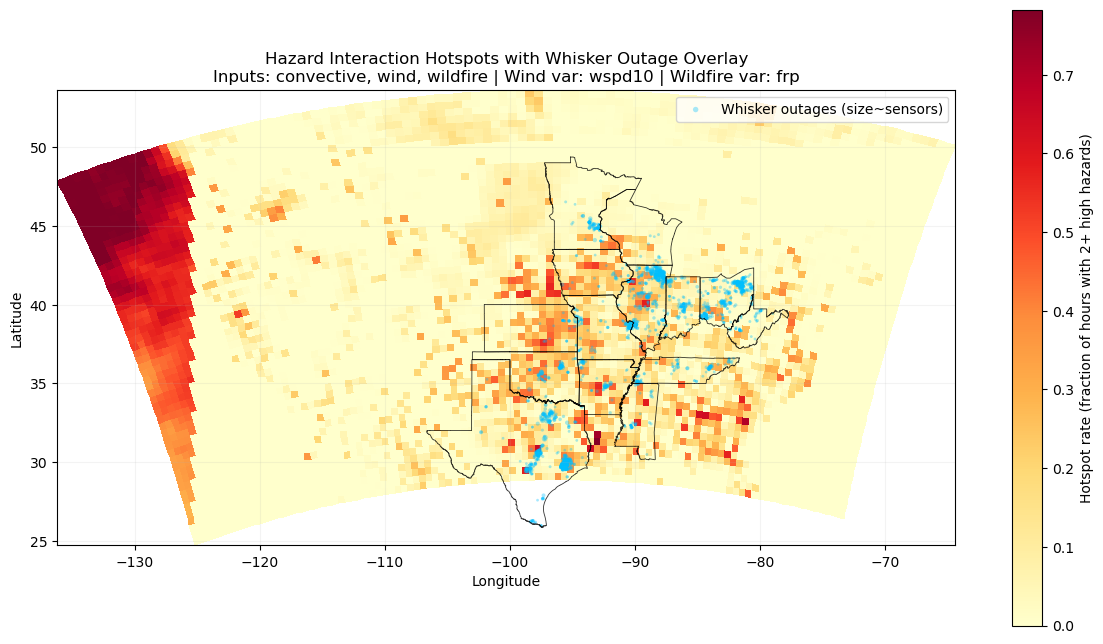

{'hotspot_mean': 0.09560127372627374, 'hotspot_p95': 0.5654761904761905, 'whisker_points_overlayed': 2009}


In [22]:
# Interaction hotspot map with Whisker impact overlay
if "gridded_hazards" not in globals():
    raise RuntimeError("gridded_hazards missing. Run hazard ingest cells first.")
if "whisker_df" not in globals():
    raise RuntimeError("whisker_df missing. Run impact ingest cell first.")


ds_tw = gridded_hazards["terrestrial_weather_gridded"]
ds_wf = gridded_hazards.get("wildfire_gridded")

if "convective_proxy" not in ds_tw.data_vars:
    raise RuntimeError("convective_proxy not found. Run convective proxy builder cell first.")

# Choose wind variable, preferring a speed product if available
wind_var = None
for cand in ["wspd10", "wind_speed", "u10", "v10"]:
    if cand in ds_tw.data_vars:
        wind_var = cand
        break
if wind_var is None:
    raise RuntimeError("No wind variable available for hotspot interaction.")

wildfire_var = None
if ds_wf is not None and len(ds_wf.data_vars) > 0:
    wildfire_var = list(ds_wf.data_vars)[0]


def _clean_arr(a):
    a = np.asarray(a, dtype=float)
    a[a <= -900] = np.nan
    return a


def _binary_q80(a):
    out = np.zeros(a.shape, dtype=np.uint8)
    good = np.isfinite(a)
    if not good.any():
        return out
    thr = np.nanquantile(a[good], 0.80)
    out[good] = (a[good] >= thr).astype(np.uint8)
    return out


conv = _clean_arr(ds_tw["convective_proxy"].values)
wind = _clean_arr(ds_tw[wind_var].values)

b_conv = _binary_q80(conv)
b_wind = _binary_q80(wind)

cubes = [b_conv, b_wind]
labels = ["convective", "wind"]

if wildfire_var is not None:
    wf = _clean_arr(ds_wf[wildfire_var].values)
    b_wf = _binary_q80(wf)
    ntime = min(b_conv.shape[0], b_wind.shape[0], b_wf.shape[0])
    b_conv = b_conv[:ntime]
    b_wind = b_wind[:ntime]
    b_wf = b_wf[:ntime]
    cubes = [b_conv, b_wind, b_wf]
    labels = ["convective", "wind", "wildfire"]
else:
    ntime = min(b_conv.shape[0], b_wind.shape[0])
    b_conv = b_conv[:ntime]
    b_wind = b_wind[:ntime]

# Hotspot score: fraction of timesteps where 2+ hazards are concurrently high
combo = (np.sum(np.stack(cubes, axis=0), axis=0) >= 2).astype(np.uint8)
hotspot_rate = combo.mean(axis=0)

lat2d = ds_grid["lat"].values
lon2d = ds_grid["lon"].values

# Whisker overlay (recent event window points already filtered in whisker_df)
wplot = whisker_df.dropna(subset=["lat", "lon"]).copy()

fig, ax = plt.subplots(1, 1, figsize=(12, 8))

mesh = ax.pcolormesh(
    lon2d,
    lat2d,
    hotspot_rate,
    shading="auto",
    cmap="YlOrRd",
    vmin=0,
    vmax=max(0.05, float(np.nanquantile(hotspot_rate[np.isfinite(hotspot_rate)], 0.99))),
)

if "gdf_aoi" in globals() and isinstance(gdf_aoi, gpd.GeoDataFrame):
    gdf_aoi.to_crs("EPSG:4326").boundary.plot(ax=ax, color="black", linewidth=0.6, alpha=0.8)

if "gdf_powergrid_aoi" in globals() and isinstance(gdf_powergrid_aoi, gpd.GeoDataFrame):
    gdf_powergrid_aoi.to_crs("EPSG:4326").plot(ax=ax, color="none", edgecolor="dimgray", linewidth=0.25, alpha=0.35)

if len(wplot) > 0:
    s = np.sqrt(wplot["sensors"].fillna(1).clip(lower=1).values) * 2.0
    ax.scatter(
        wplot["lon"],
        wplot["lat"],
        s=s,
        c="deepskyblue",
        alpha=0.35,
        edgecolor="none",
        label="Whisker outages (size~sensors)",
    )

cbar = fig.colorbar(mesh, ax=ax, shrink=0.8)
cbar.set_label("Hotspot rate (fraction of hours with 2+ high hazards)")

ax.set_title(
    "Hazard Interaction Hotspots with Whisker Outage Overlay\n"
    f"Inputs: {', '.join(labels)} | Wind var: {wind_var} | Wildfire var: {wildfire_var if wildfire_var else 'None'}"
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(loc="upper right", frameon=True)
ax.grid(alpha=0.15)
plt.tight_layout()
plt.show()

print({
    "hotspot_mean": float(np.nanmean(hotspot_rate)),
    "hotspot_p95": float(np.nanquantile(hotspot_rate[np.isfinite(hotspot_rate)], 0.95)),
    "whisker_points_overlayed": int(len(wplot)),
})

## Step 3d: Lagged Hazard-to-Impact Skill Scoring

Build a time-aligned hazard-feature table and score lead-lag predictive skill against impact targets from Eagle-I and Whisker. This provides a first-pass ranking of candidate predictors (including the convective proxy).

/var/folders/g_/2j33jfhn72j448cr82hzgr0c0002d4/T/ipykernel_9413/3172887852.py:30: RuntimeWarning: Mean of empty slice
  mean_ts = np.nanmean(arr, axis=(1, 2))
/Users/ryanmc/miniforge3/envs/spwxr_network_new/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


Aligned rows for scoring: 336
Predictor columns: 20

Top predictors for Eagle-I spike target:
                              predictor  lag_h  best_auc  spearman_rho   n
                               v10__q95      2  0.989314      0.512547 334
  MultiSensor_QPE_24H_Pass2_00.00__mean      0  0.944001      0.463853 336
   MultiSensor_QPE_24H_Pass2_00.00__q95      0  0.935723      0.455204 336
 MergedReflectivityComposite_00.50__q95     12  0.931440      0.458050 324
                              v10__mean     12  0.930527      0.457074 324
                              u10__mean      0  0.924133      0.443097 336
                               u10__q95      3  0.888157      0.407127 333
                           wspd10__mean      3  0.830809      0.346977 333
                            wspd10__q95      2  0.810490      0.325233 334
MergedReflectivityComposite_00.50__mean     12  0.786613      0.304286 324
                  convective_proxy__q95     12  0.774189      0.298238 324
      

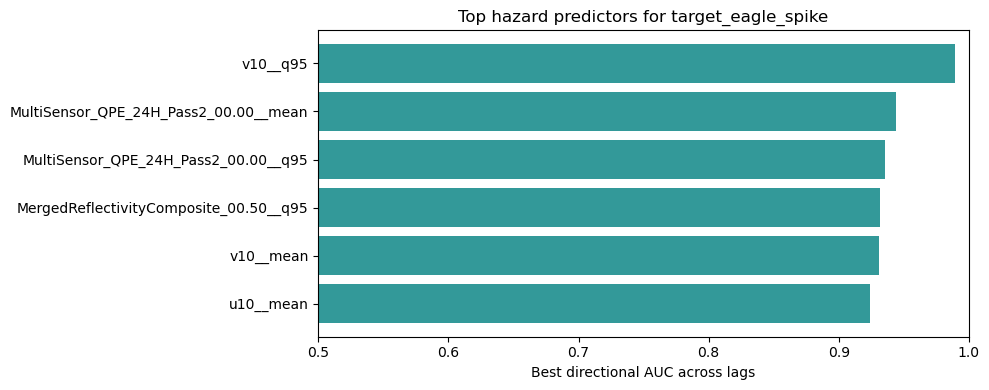

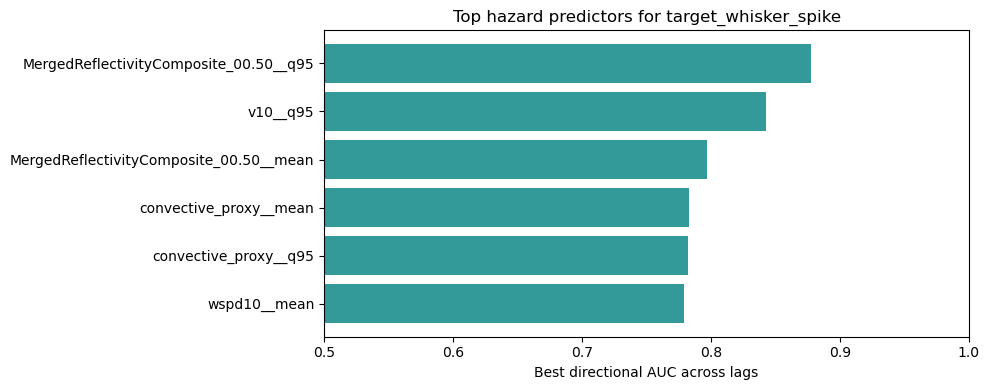

In [24]:
# First-pass lagged predictor scoring against Eagle-I and Whisker impacts
from scipy.stats import spearmanr, rankdata

if "impact_panel" not in globals():
    raise RuntimeError("impact_panel is missing. Run the Step 3c impact ingest cell first.")
if "gridded_hazards" not in globals():
    raise RuntimeError("gridded_hazards is missing. Run hazard ingest cells first.")


def _as_utc_hour_index(idx_or_series):
    ts = pd.to_datetime(idx_or_series, errors="coerce", utc=True)
    return pd.DatetimeIndex(ts).floor("h")


def _clean_hazard_array(a):
    arr = np.asarray(a, dtype=float)
    arr[arr <= -900] = np.nan
    return arr


def _spatial_feature_timeseries(ds, var_name, q=0.95):
    if ds is None or var_name is None or var_name not in ds.data_vars:
        return None
    da = ds[var_name]
    arr = _clean_hazard_array(da.values)
    if arr.ndim != 3:
        return None

    with np.errstate(invalid="ignore"):
        mean_ts = np.nanmean(arr, axis=(1, 2))
        q_ts = np.nanquantile(arr, q, axis=(1, 2))

    t = _as_utc_hour_index(da["time"].values)
    out = pd.DataFrame({
        f"{var_name}__mean": mean_ts,
        f"{var_name}__q{int(q*100)}": q_ts,
    }, index=t)
    out = out[~out.index.duplicated(keep="first")].sort_index()
    return out


def _binary_auc(y_true, y_score):
    y_true = np.asarray(y_true, dtype=int)
    y_score = np.asarray(y_score, dtype=float)
    ok = np.isfinite(y_score)
    y_true = y_true[ok]
    y_score = y_score[ok]
    if len(y_true) < 10:
        return np.nan
    n_pos = int((y_true == 1).sum())
    n_neg = int((y_true == 0).sum())
    if n_pos == 0 or n_neg == 0:
        return np.nan
    ranks = rankdata(y_score)
    sum_pos = ranks[y_true == 1].sum()
    auc = (sum_pos - n_pos * (n_pos + 1) / 2.0) / (n_pos * n_neg)
    return float(auc)


# 1) Build impact targets at hourly resolution
impact_hourly = (
    impact_panel
    .copy()
    .assign(hour=lambda d: _as_utc_hour_index(d["hour"]))
    .groupby("hour", as_index=True)
    .agg(
        eagle_total_out=("eagle_customers_out", "sum"),
        whisker_event_count=("whisker_event_count", "sum"),
        whisker_sensors_sum=("whisker_sensors_sum", "sum"),
    )
    .sort_index()
)

impact_hourly["target_eagle_spike"] = (
    impact_hourly["eagle_total_out"] >= impact_hourly["eagle_total_out"].quantile(0.90)
).astype(int)
impact_hourly["target_whisker_spike"] = (
    impact_hourly["whisker_event_count"] >= impact_hourly["whisker_event_count"].quantile(0.90)
).astype(int)

# 2) Build predictor list (ensure convective proxy included)
ds_tw = gridded_hazards.get("terrestrial_weather_gridded")
ds_wf = gridded_hazards.get("wildfire_gridded")
ds_sw = gridded_hazards.get("space_weather_gridded")

predictor_specs = []

if ds_tw is not None and "convective_proxy" in ds_tw.data_vars:
    predictor_specs.append(("tw", "convective_proxy"))

for cand in ["wspd10", "u10", "v10", "MAX_SHEAR", "MergedReflectivityComposite_00.50", "MultiSensor_QPE_24H_Pass2_00.00"]:
    if ds_tw is not None and cand in ds_tw.data_vars and ("tw", cand) not in predictor_specs:
        predictor_specs.append(("tw", cand))

if ds_wf is not None:
    for cand in ["frp"]:
        if cand in ds_wf.data_vars and ("wf", cand) not in predictor_specs:
            predictor_specs.append(("wf", cand))
    if len(ds_wf.data_vars) > 0:
        fallback = list(ds_wf.data_vars)[0]
        if ("wf", fallback) not in predictor_specs:
            predictor_specs.append(("wf", fallback))

if ds_sw is not None:
    for cand in ["Bh", "Eh"]:
        if cand in ds_sw.data_vars and ("sw", cand) not in predictor_specs:
            predictor_specs.append(("sw", cand))
    if len(ds_sw.data_vars) > 0:
        fallback = list(ds_sw.data_vars)[0]
        if ("sw", fallback) not in predictor_specs:
            predictor_specs.append(("sw", fallback))

# 3) Build predictor dataframe
feature_frames = []
for fam, var in predictor_specs:
    ds = ds_tw if fam == "tw" else (ds_wf if fam == "wf" else ds_sw)
    feat = _spatial_feature_timeseries(ds, var, q=0.95)
    if feat is not None and len(feat) > 0:
        feature_frames.append(feat)

if not feature_frames:
    raise RuntimeError("No hazard predictor features could be built.")

hazard_hourly = pd.concat(feature_frames, axis=1).sort_index()

# 4) Align predictors + targets
model_df = hazard_hourly.join(impact_hourly, how="inner").sort_index()

# Keep finite predictors only for scoring
predictor_cols = [c for c in hazard_hourly.columns if c in model_df.columns]

if len(model_df) < 24:
    raise RuntimeError(f"Too few aligned hourly rows for scoring: {len(model_df)}")

# 5) Score lags
lags = list(range(0, 13))  # 0-12 hours lead
rows = []

for target_col in ["target_eagle_spike", "target_whisker_spike"]:
    for pcol in predictor_cols:
        x0 = model_df[pcol].astype(float)
        y0 = model_df[target_col].astype(int)

        for lag in lags:
            if lag == 0:
                x = x0.values
                y = y0.values
            else:
                x = x0.values[:-lag]
                y = y0.values[lag:]

            ok = np.isfinite(x) & np.isfinite(y)
            if ok.sum() < 20:
                continue

            xr = x[ok]
            yr = y[ok].astype(int)

            rho, _ = spearmanr(xr, yr)
            auc = _binary_auc(yr, xr)
            best_auc = np.nanmax([auc, 1.0 - auc]) if np.isfinite(auc) else np.nan

            rows.append({
                "target": target_col,
                "predictor": pcol,
                "lag_h": lag,
                "n": int(ok.sum()),
                "spearman_rho": float(rho) if np.isfinite(rho) else np.nan,
                "auc": auc,
                "best_auc": float(best_auc) if np.isfinite(best_auc) else np.nan,
            })

skill_long = pd.DataFrame(rows)
if skill_long.empty:
    raise RuntimeError("Skill table is empty. Check predictor/target overlap and finite values.")

# 6) Best lag summary per predictor/target
skill_best = (
    skill_long
    .sort_values(["target", "predictor", "best_auc", "spearman_rho"], ascending=[True, True, False, False])
    .groupby(["target", "predictor"], as_index=False)
    .first()
    .sort_values(["target", "best_auc", "spearman_rho"], ascending=[True, False, False])
)

print("Aligned rows for scoring:", len(model_df))
print("Predictor columns:", len(predictor_cols))
print("\nTop predictors for Eagle-I spike target:")
print(
    skill_best[skill_best["target"] == "target_eagle_spike"]
    [["predictor", "lag_h", "best_auc", "spearman_rho", "n"]]
    .head(12)
    .to_string(index=False)
)

print("\nTop predictors for Whisker spike target:")
print(
    skill_best[skill_best["target"] == "target_whisker_spike"]
    [["predictor", "lag_h", "best_auc", "spearman_rho", "n"]]
    .head(12)
    .to_string(index=False)
)

# 7) Quick visualization for top 6 predictors per target
for target_col in ["target_eagle_spike", "target_whisker_spike"]:
    top = skill_best[skill_best["target"] == target_col].head(6)
    if top.empty:
        continue

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(top["predictor"][::-1], top["best_auc"][::-1], color="teal", alpha=0.8)
    ax.set_xlim(0.5, 1.0)
    ax.set_xlabel("Best directional AUC across lags")
    ax.set_title(f"Top hazard predictors for {target_col}")
    plt.tight_layout()
    plt.show()

# Persist outputs for next cells
hazard_obs_skill_long = skill_long
hazard_obs_skill_best = skill_best
hazard_obs_model_df = model_df

## Step 3e: Multi-Hazard Event Chronology (With Spatial Modes)

Build a five-panel chronology that combines:
- Multi-hazard intensity proxy (convective + wildfire + space weather)
- Sag counts per hour (inside/outside CBEMA)
- Outage counts per hour
- Swell counts per hour
- Frequency-jump counts per hour

Spatial handling for hazard intensity is explicit via `SPATIAL_MODE`:
- `"conus_mean"`: equal-weight mean over all grid cells
- `"aoi_mean"`: mean over AOI grid cells only
- `"hotspot_weighted"`: weighted by persistent multi-hazard hotspot rate (preferred when focusing on impact-prone locations)

The cell also computes and overlays vertical markers for hazard onset, peak, and end.

/var/folders/g_/2j33jfhn72j448cr82hzgr0c0002d4/T/ipykernel_9413/2819782612.py:40: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  aoi_union = gdf_aoi_ll.unary_union
/var/folders/g_/2j33jfhn72j448cr82hzgr0c0002d4/T/ipykernel_9413/2819782612.py:270: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out_ct = e.groupby("hour").apply(lambda d: int((d["customers_out"] > 0).sum()))


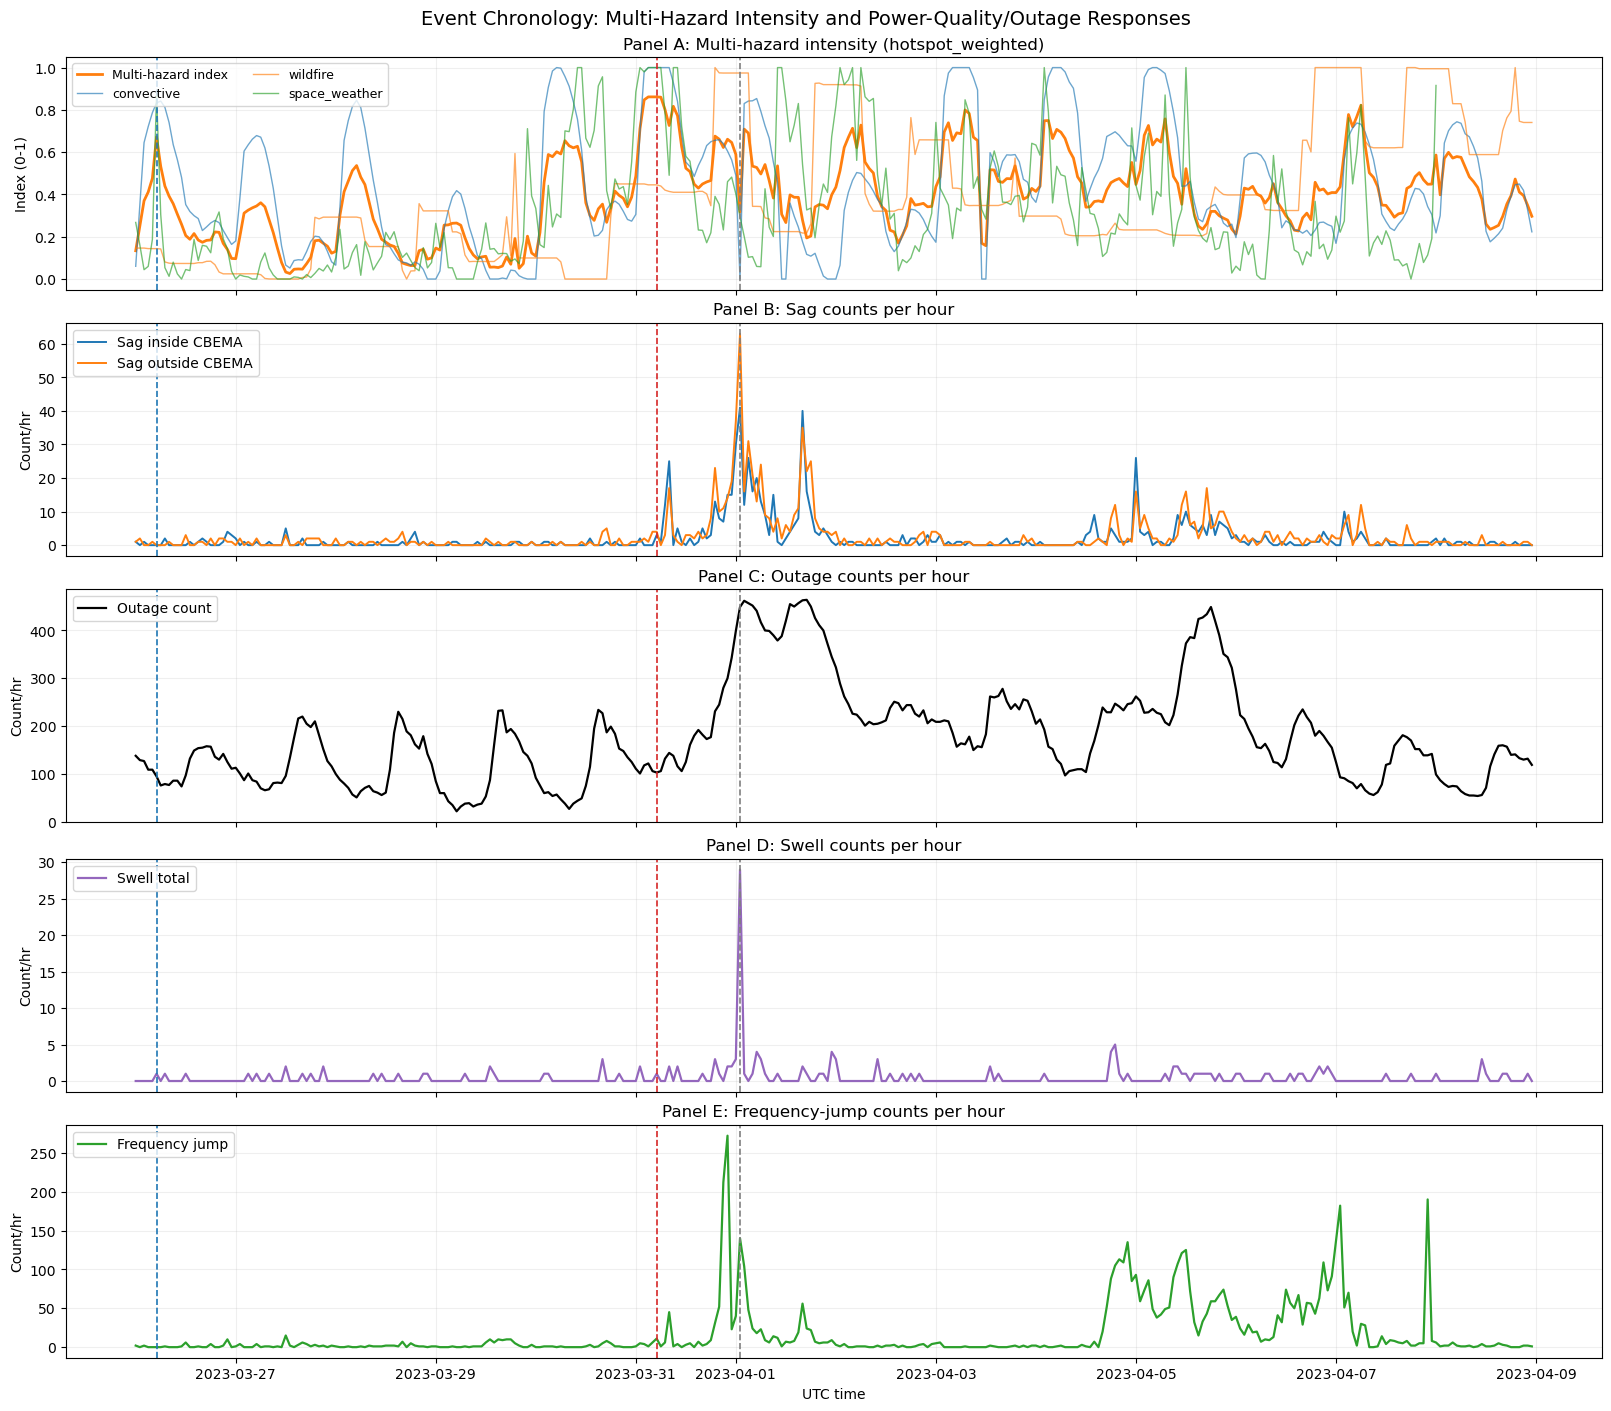

Chronology markers:
{'spatial_mode': 'hotspot_weighted', 'onset': '2023-03-26 05:00:00+00:00', 'peak': '2023-03-31 05:00:00+00:00', 'end': '2023-04-01 01:00:00+00:00', 'convective_var': 'convective_proxy', 'wildfire_var': 'frp', 'space_weather_var': 'Eh'}


In [25]:
# Multi-hazard chronology with explicit spatial handling
from pathlib import Path

if "gridded_hazards" not in globals():
    raise RuntimeError("gridded_hazards is missing. Run hazard ingest cells first.")


def _as_utc_hour_index(x):
    ts = pd.to_datetime(x, errors="coerce", utc=True)
    return pd.DatetimeIndex(ts).floor("h")


def _clean_hazard_arr(a):
    arr = np.asarray(a, dtype=float)
    arr[arr <= -900] = np.nan
    return arr


def _robust_unit_scale(s):
    s = pd.Series(s, dtype=float)
    good = s.dropna()
    if good.empty:
        return s * np.nan
    q05, q95 = good.quantile([0.05, 0.95])
    if not np.isfinite(q95 - q05) or (q95 - q05) <= 1e-12:
        q05, q95 = float(good.min()), float(good.max())
    if not np.isfinite(q95 - q05) or (q95 - q05) <= 1e-12:
        return pd.Series(np.full(len(s), 0.5, dtype=float), index=s.index)
    out = (s - q05) / (q95 - q05)
    return out.clip(0.0, 1.0)


def _build_aoi_mask_2d(ds_ref, gdf_aoi_local):
    if ds_ref is None or "lat" not in ds_ref.coords or "lon" not in ds_ref.coords:
        return None
    if gdf_aoi_local is None or len(gdf_aoi_local) == 0:
        return None

    gdf_aoi_ll = gdf_aoi_local.to_crs("EPSG:4326")
    aoi_union = gdf_aoi_ll.unary_union

    lat2d = ds_ref["lat"].values
    lon2d = ds_ref["lon"].values
    ny, nx = lat2d.shape

    pts = gpd.GeoDataFrame(
        geometry=gpd.points_from_xy(lon2d.ravel(), lat2d.ravel()),
        crs="EPSG:4326",
    )
    mask_flat = pts.within(aoi_union).values
    return mask_flat.reshape(ny, nx)


def _timeseries_from_da(da, mode="conus_mean", mask2d=None, weights2d=None):
    if da is None:
        return None
    arr = _clean_hazard_arr(da.values)
    if arr.ndim != 3:
        return None

    if mode == "conus_mean":
        vals = np.nanmean(arr, axis=(1, 2))
    elif mode == "aoi_mean":
        if mask2d is None:
            vals = np.nanmean(arr, axis=(1, 2))
        else:
            vals = np.array([np.nanmean(arr[t][mask2d]) for t in range(arr.shape[0])], dtype=float)
    elif mode == "hotspot_weighted":
        if weights2d is None:
            vals = np.nanmean(arr, axis=(1, 2))
        else:
            w = np.asarray(weights2d, dtype=float)
            w = np.where(np.isfinite(w), w, 0.0)
            if np.nansum(w) <= 0:
                vals = np.nanmean(arr, axis=(1, 2))
            else:
                w = w / np.nansum(w)
                vals = np.array([np.nansum(arr[t] * w) for t in range(arr.shape[0])], dtype=float)
    else:
        raise ValueError(f"Unknown spatial mode: {mode}")

    idx = _as_utc_hour_index(da["time"].values)
    out = pd.Series(vals, index=idx)
    out = out[~out.index.duplicated(keep="first")].sort_index()
    return out


# ---- 1) Build multi-hazard proxy components ----
ds_tw = gridded_hazards.get("terrestrial_weather_gridded")
ds_wf = gridded_hazards.get("wildfire_gridded")
ds_sw = gridded_hazards.get("space_weather_gridded")

if ds_tw is None or "convective_proxy" not in ds_tw.data_vars:
    raise RuntimeError("convective_proxy missing. Run Step 3c convective proxy cell first.")

wildfire_var = None
if ds_wf is not None and len(ds_wf.data_vars) > 0:
    wildfire_var = "frp" if "frp" in ds_wf.data_vars else list(ds_wf.data_vars)[0]

space_var = None
if ds_sw is not None and len(ds_sw.data_vars) > 0:
    for cand in ["Eh", "Bh"]:
        if cand in ds_sw.data_vars:
            space_var = cand
            break
    if space_var is None:
        space_var = list(ds_sw.data_vars)[0]

# Spatial mode for Panel A
SPATIAL_MODE = "hotspot_weighted"  # options: conus_mean, aoi_mean, hotspot_weighted

# AOI mask for optional AOI-only aggregation
if "gdf_aoi" in globals() and isinstance(gdf_aoi, gpd.GeoDataFrame):
    aoi_mask2d = _build_aoi_mask_2d(ds_tw, gdf_aoi)
else:
    aoi_mask2d = None

# Hotspot weights for optional hotspot-weighted aggregation
# Build as fraction of hours where >=2 hazards exceed q80 at a grid cell.
def _binary_q80_cube(da):
    a = _clean_hazard_arr(da.values)
    good = np.isfinite(a)
    out = np.zeros(a.shape, dtype=np.uint8)
    if good.any():
        thr = np.nanquantile(a[good], 0.80)
        out[good] = (a[good] >= thr).astype(np.uint8)
    return out

cubes = []
cubes.append(_binary_q80_cube(ds_tw["convective_proxy"]))
if wildfire_var is not None:
    cubes.append(_binary_q80_cube(ds_wf[wildfire_var]))
if space_var is not None:
    cubes.append(_binary_q80_cube(ds_sw[space_var]))

ntime = min(c.shape[0] for c in cubes)
cubes = [c[:ntime] for c in cubes]
combo = (np.sum(np.stack(cubes, axis=0), axis=0) >= 2).astype(np.uint8)
hotspot_rate_2d = combo.mean(axis=0)
hotspot_weights_2d = np.where(np.isfinite(hotspot_rate_2d), hotspot_rate_2d, 0.0)
if np.nansum(hotspot_weights_2d) > 0:
    hotspot_weights_2d = hotspot_weights_2d / np.nansum(hotspot_weights_2d)
else:
    hotspot_weights_2d = None

conv_ts = _timeseries_from_da(
    ds_tw["convective_proxy"],
    mode=SPATIAL_MODE,
    mask2d=aoi_mask2d,
    weights2d=hotspot_weights_2d,
)
wf_ts = _timeseries_from_da(
    ds_wf[wildfire_var],
    mode=SPATIAL_MODE,
    mask2d=aoi_mask2d,
    weights2d=hotspot_weights_2d,
) if wildfire_var is not None else None
sw_ts = _timeseries_from_da(
    ds_sw[space_var],
    mode=SPATIAL_MODE,
    mask2d=aoi_mask2d,
    weights2d=hotspot_weights_2d,
) if space_var is not None else None

haz_df = pd.DataFrame(index=conv_ts.index)
haz_df["convective"] = conv_ts
if wf_ts is not None:
    haz_df["wildfire"] = wf_ts.reindex(haz_df.index)
if sw_ts is not None:
    haz_df["space_weather"] = sw_ts.reindex(haz_df.index)

for c in list(haz_df.columns):
    haz_df[f"{c}_norm"] = _robust_unit_scale(haz_df[c])

w_map = {
    "convective_norm": 0.50,
    "wildfire_norm": 0.25,
    "space_weather_norm": 0.25,
}
active_cols = [c for c in w_map if c in haz_df.columns]
w = np.array([w_map[c] for c in active_cols], dtype=float)
w = w / w.sum()
haz_df["multi_hazard_index"] = np.nansum(
    np.column_stack([haz_df[c].values for c in active_cols]) * w.reshape(1, -1),
    axis=1,
)

# Keep only event window and hourly UTC index
event_hours = pd.date_range(EVENT_START.floor("h"), EVENT_END.floor("h"), freq="1h", tz="UTC")
haz_df = haz_df.reindex(event_hours)


# ---- 2) Build hourly Whisker event channels (sag/swell/frequency/frequency jump) ----
WHISKER_DIR = Path(
    "/Users/ryanmc/Documents/NASA_JPL/Projects/NaturalHazards/NASA ROSES Disasters 2025-2027/data/Whisker_Labs_Data_March2026/2023-03-26 to 2023-04-09 Event"
)

event_file_map = {
    "Frequency": "Frequency.json",
    "Sag_Inside_CBEMA": "Sags_Inside_CBEMA.json",
    "Sag_Outside_CBEMA": "Sags_Outside_CBEMA.json",
    "Swell_Inside_CBEMA": "Swells_Inside_CBEMA.json",
    "Swell_Outside_CBEMA": "Swells_Outside_CBEMA.json",
}

rows = []
for group_name, fn in event_file_map.items():
    fp = WHISKER_DIR / fn
    if not fp.exists():
        continue
    with open(fp, "r", encoding="utf-8") as f:
        raw = json.load(f)

    if isinstance(raw, dict) and "features" in raw:
        it = raw["features"]
    elif isinstance(raw, list):
        it = raw
    else:
        continue

    for r in it:
        rows.append({
            "event_group": group_name,
            "event_type": r.get("Type", group_name),
            "start_utc": pd.to_datetime(r.get("StartTime"), errors="coerce", utc=True),
            "average_amplitude": pd.to_numeric(r.get("AverageAmplitude"), errors="coerce"),
        })

events = pd.DataFrame(rows)
if events.empty:
    raise RuntimeError("No Whisker event files loaded for chronology panels.")

events = events.dropna(subset=["start_utc"]).copy()
events = events[(events["start_utc"] >= EVENT_START) & (events["start_utc"] <= EVENT_END)].copy()
events["hour"] = events["start_utc"].dt.floor("h")

chron = pd.DataFrame(index=event_hours)
chron["sag_inside_count"] = (
    events[events["event_group"] == "Sag_Inside_CBEMA"]
    .groupby("hour").size().reindex(event_hours, fill_value=0)
)
chron["sag_outside_count"] = (
    events[events["event_group"] == "Sag_Outside_CBEMA"]
    .groupby("hour").size().reindex(event_hours, fill_value=0)
)
chron["swell_total_count"] = (
    events[events["event_group"].isin(["Swell_Inside_CBEMA", "Swell_Outside_CBEMA"])]
    .groupby("hour").size().reindex(event_hours, fill_value=0)
)

freq_mask = events["event_group"] == "Frequency"
freq_jump_mask = freq_mask & events["event_type"].astype(str).str.contains("jump", case=False, na=False)
if int(freq_jump_mask.sum()) == 0:
    # Fallback when type tags are absent
    freq_jump_mask = freq_mask

chron["frequency_jump_count"] = (
    events[freq_jump_mask]
    .groupby("hour").size().reindex(event_hours, fill_value=0)
)


# ---- 3) Outage count per hour (prefer Eagle-I county count > 0) ----
if "eaglei_data" in globals() and isinstance(eaglei_data, pd.DataFrame) and len(eaglei_data) > 0:
    e = eaglei_data.copy()
    e["hour"] = _as_utc_hour_index(e["run_start_time"])
    if "customers_out" in e.columns:
        e = e[np.isfinite(pd.to_numeric(e["customers_out"], errors="coerce"))].copy()
        e["customers_out"] = pd.to_numeric(e["customers_out"], errors="coerce")
        out_ct = e.groupby("hour").apply(lambda d: int((d["customers_out"] > 0).sum()))
    else:
        out_ct = e.groupby("hour").size().astype(int)
    chron["outage_count"] = out_ct.reindex(event_hours, fill_value=0)
elif "impact_panel" in globals() and isinstance(impact_panel, pd.DataFrame) and len(impact_panel) > 0:
    ip = impact_panel.copy()
    ip["hour"] = _as_utc_hour_index(ip["hour"])
    if "eagle_customers_out" in ip.columns:
        tmp = (
            ip.groupby(["hour", "county_fips"], as_index=False)
            .agg(eagle_customers_out=("eagle_customers_out", "max"))
        )
        out_ct = tmp.groupby("hour").apply(lambda d: int((pd.to_numeric(d["eagle_customers_out"], errors="coerce") > 0).sum()))
        chron["outage_count"] = out_ct.reindex(event_hours, fill_value=0)
    else:
        chron["outage_count"] = 0
else:
    # Fallback to Whisker power outage events
    power_fp = WHISKER_DIR / "PowerOutages.json"
    if power_fp.exists():
        with open(power_fp, "r", encoding="utf-8") as f:
            prow = json.load(f)
        pit = prow["features"] if isinstance(prow, dict) and "features" in prow else (prow if isinstance(prow, list) else [])
        p_df = pd.DataFrame({
            "start_utc": [pd.to_datetime(r.get("StartTime"), errors="coerce", utc=True) for r in pit]
        }).dropna()
        p_df = p_df[(p_df["start_utc"] >= EVENT_START) & (p_df["start_utc"] <= EVENT_END)].copy()
        p_df["hour"] = p_df["start_utc"].dt.floor("h")
        chron["outage_count"] = p_df.groupby("hour").size().reindex(event_hours, fill_value=0)
    else:
        chron["outage_count"] = 0


# ---- 4) Merge with hazard index and compute markers ----
panel = chron.join(haz_df[["multi_hazard_index"] + active_cols], how="left")
panel["multi_hazard_index"] = panel["multi_hazard_index"].interpolate(limit_direction="both")

for c in ["sag_inside_count", "sag_outside_count", "swell_total_count", "outage_count", "frequency_jump_count"]:
    panel[c] = pd.to_numeric(panel[c], errors="coerce").fillna(0.0)

mh = panel["multi_hazard_index"].copy()
if mh.isna().all():
    raise RuntimeError("Multi-hazard index is all-NaN; check hazard datasets and spatial mode.")

thr_onset = float(mh.quantile(0.75))
thr_end = float(mh.quantile(0.50))

onset_candidates = mh[mh >= thr_onset]
onset_time = onset_candidates.index[0] if len(onset_candidates) else mh.index[0]
peak_time = mh.idxmax()
post_peak = mh.loc[peak_time:]
end_candidates = post_peak[post_peak <= thr_end]
end_time = end_candidates.index[0] if len(end_candidates) else post_peak.index[-1]


# ---- 5) Plot event chronology Panels A-E ----
fig, axes = plt.subplots(5, 1, figsize=(16, 14), sharex=True, constrained_layout=True)

# Panel A: multi-hazard intensity
axes[0].plot(panel.index, panel["multi_hazard_index"], color="tab:orange", linewidth=2.0, label="Multi-hazard index")
for c in active_cols:
    axes[0].plot(panel.index, panel[c], linewidth=1.0, alpha=0.65, label=c.replace("_norm", ""))
axes[0].set_ylabel("Index (0-1)")
axes[0].set_title(f"Panel A: Multi-hazard intensity ({SPATIAL_MODE})")
axes[0].legend(loc="upper left", ncol=2, fontsize=9)
axes[0].grid(alpha=0.2)

# Panel B: sag inside/outside CBEMA
axes[1].plot(panel.index, panel["sag_inside_count"], linewidth=1.4, label="Sag inside CBEMA")
axes[1].plot(panel.index, panel["sag_outside_count"], linewidth=1.4, label="Sag outside CBEMA")
axes[1].set_ylabel("Count/hr")
axes[1].set_title("Panel B: Sag counts per hour")
axes[1].legend(loc="upper left")
axes[1].grid(alpha=0.2)

# Panel C: outage counts per hour
axes[2].plot(panel.index, panel["outage_count"], color="black", linewidth=1.6, label="Outage count")
axes[2].set_ylabel("Count/hr")
axes[2].set_title("Panel C: Outage counts per hour")
axes[2].legend(loc="upper left")
axes[2].grid(alpha=0.2)

# Panel D: swell counts per hour
axes[3].plot(panel.index, panel["swell_total_count"], color="tab:purple", linewidth=1.6, label="Swell total")
axes[3].set_ylabel("Count/hr")
axes[3].set_title("Panel D: Swell counts per hour")
axes[3].legend(loc="upper left")
axes[3].grid(alpha=0.2)

# Panel E: frequency jump counts per hour
axes[4].plot(panel.index, panel["frequency_jump_count"], color="tab:green", linewidth=1.6, label="Frequency jump")
axes[4].set_ylabel("Count/hr")
axes[4].set_title("Panel E: Frequency-jump counts per hour")
axes[4].legend(loc="upper left")
axes[4].grid(alpha=0.2)

for i, ax in enumerate(axes):
    ax.axvline(onset_time, color="tab:blue", linestyle="--", linewidth=1.2, label="Hazard onset" if i == 0 else None)
    ax.axvline(peak_time, color="tab:red", linestyle="--", linewidth=1.2, label="Hazard peak" if i == 0 else None)
    ax.axvline(end_time, color="tab:gray", linestyle="--", linewidth=1.2, label="Hazard end" if i == 0 else None)

axes[-1].set_xlabel("UTC time")
fig.suptitle("Event Chronology: Multi-Hazard Intensity and Power-Quality/Outage Responses", fontsize=14)
plt.show()

print("Chronology markers:")
print({
    "spatial_mode": SPATIAL_MODE,
    "onset": str(onset_time),
    "peak": str(peak_time),
    "end": str(end_time),
    "convective_var": "convective_proxy",
    "wildfire_var": wildfire_var,
    "space_weather_var": space_var,
})

# Persist output for reuse
event_chronology_panel = panel
event_hazard_markers = {
    "onset": onset_time,
    "peak": peak_time,
    "end": end_time,
    "spatial_mode": SPATIAL_MODE,
}